# Two Digit Classifier (0-99)
> *Costella Matteo - Deep Learning and Generative Models - A.A. 2025/26*


In [7]:
import os
import torch
from torchvision.utils import make_grid, save_image
from torchvision.datasets import MNIST
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [8]:
BASE = "/kaggle/working"
paths = [
    f"{BASE}/dataset",
    f"{BASE}/configs",
    f"{BASE}/data/mnist",
    f"{BASE}/data/mnist99",
    f"{BASE}/artifacts",
]

for p in paths:
    os.makedirs(p, exist_ok=True)

for p in paths:
    print(p)


/kaggle/working/dataset
/kaggle/working/configs
/kaggle/working/data/mnist
/kaggle/working/data/mnist99
/kaggle/working/artifacts


# Building MNIST99 Dataset
> *This chapter will focus on the creation of a new dataset for two-digit-classifier task. This new ds, created from MNIST dataset, will be formed by images representing the 100 classes to classify (0..99 numbers).*

> *Images representing the numbers 0..9 will have to contain only one digit (not 00..09).*

## Download dataset MNIST

In [9]:
mnist_root = "/kaggle/working/data/mnist"

# MNIST train e test
# Convert to tensor
mnist_train = MNIST(root=mnist_root, train=True, download=True, transform=transforms.ToTensor())
mnist_test  = MNIST(root=mnist_root, train=False, download=True, transform=transforms.ToTensor())

# must be 60000
print("Train size:", len(mnist_train))

# must be 10000
print("Test size:", len(mnist_test))

t, l = mnist_train[0]

# must be 1x28x28
print("tensor:",t.shape, "label:", l)

# must be normalized between 0 and 1
print("min/max:", float(t.min()), float(t.max()))

Train size: 60000
Test size: 10000
tensor: torch.Size([1, 28, 28]) label: 5
min/max: 0.0 1.0


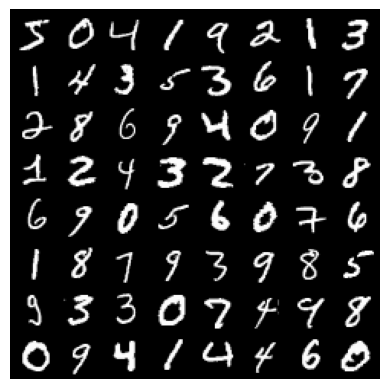

In [13]:
# create a grid to show some data we'll have to deal with
imgs = torch.stack([mnist_train[i][0] for i in range(64)], dim=0)
grid = make_grid(imgs, nrow=8, padding=2)

out_path = "/kaggle/working/artifacts/mnist_grid.png"
save_image(grid, out_path)
out_path


img = Image.open("/kaggle/working/artifacts/mnist_grid.png")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()


## Dataset configuration file (.yaml)
> *This file will contain all parameters needed during the creation of the new dataset, so they can easly be manipulated.*

> *LeNet5 architecture needs a 32x32 input image. For this task, we'll need to put two digits one alongside another, so we'll obtain a **32x64** image. It will be necessary to slightly modify the network architecture to manage these new dimensions.* 


In [14]:
%%writefile /kaggle/working/configs/dataset_conf.yaml
seed: 123    # for randomizing dataset creation, but mantain it deterministic

final_size: [32,64]    # CNN LeNet style
dtype_storage: "uint8"    # Cache saving format

cache:    # Location of cached dataset
    root: "/kaggle/working/data/mnist99"

split:
    train_val: 0.9    # 90% train, 10% val

samples_per_class:    # How many examples per-class
  train: 2000         # 2000*100 = 200000 total
  val: 300            # 30000 total
  test: 300           # 30000 total

compose:    # How the two images are composed in the new 32x64 canvas
  # Random position offset (pixel)
  offset_y: 2
  offset_x: 2

  # Random gap between the two ciphres (only for 10-99)
  gap_min: 2
  gap_max: 4

  # Margins to not touch canvas border and cut the ciphres
  pad_top: 2
  pad_left: 2


Overwriting /kaggle/working/configs/dataset_conf.yaml


## Dataset builder
> *My idea is to use a custom seed (setted in dataset_conf.yaml) to randomize the creation of the new features for the dataset.*

> *I'll use RandomState as rng because it's a deterministic one, so if we use the same seed twice, we should obtain the same identical dataset.*

> *rng will be used to select digits to combine from a pool, and also to choose the random offset/gap to apply to each digit.*


In [15]:
%%writefile /kaggle/working/dataset/mnist99_dataset.py
import os
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import numpy as np
import torch
import yaml
from torch.utils.data import Dataset

# Config loader
def load_yaml_config(path: str) -> dict:
    with open(path, "r") as f:
        cfg = yaml.safe_load(f)
    return cfg


# Creates a dictionary containing a list of index for every MNIST class.
# So i can access rapidly to every image of every class.
def build_indices_by_digit(mnist_dataset) -> Dict[int, List[int]]:
    indices_by_digit = {d: [] for d in range(10)}
    for idx in range(len(mnist_dataset)):
        _, l = mnist_dataset[idx]
        indices_by_digit[int(l)].append(idx)

    return indices_by_digit




# Extract a random imagee from indices_by_digit list matching the input digit
def sample_digit_image(digit: int, mnist_dataset, indices_by_digit: Dict[int, List[int]], rng: np.random.RandomState) -> torch.Tensor:
    pool = indices_by_digit[digit]

    # Random number
    j = int(rng.randint(0, len(pool)))

    # Extract index from pool and find the image with that index in the dataset
    idx = pool[j]
    img, l = mnist_dataset[idx]

    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img)

    return img


# Create new empty image 1xHxW
def _make_canvas(final_h: int, final_w: int, device=None, dtype=torch.float32) -> torch.Tensor:
    return torch.zeros((1, final_h, final_w), dtype=dtype, device=device)

# Create 32x64 single-digit image (0-9)
def compose_one_digit(img: torch.Tensor, cfg: dict, rng: np.random.RandomState) -> torch.Tensor:
    final_h, final_w = cfg["final_size"]
    c = _make_canvas(final_h, final_w, device=img.device, dtype=img.dtype)

    pad_top = int(cfg["compose"]["pad_top"])
    pad_left = int(cfg["compose"]["pad_left"])
    offset_y = int(cfg["compose"]["offset_y"])
    offset_x = int(cfg["compose"]["offset_x"])

    # Calculate position to center the single digit on the canvas
    # (coordinate dell'angolo top-left della nuova immagine)
    base_y = (final_h - 28) // 2
    base_x = (final_w - 28) // 2

    # Generate random offset
    dy = int(rng.randint(-offset_y, offset_y + 1)) if offset_y > 0 else 0
    dx = int(rng.randint(-offset_x, offset_x + 1)) if offset_x > 0 else 0

    # New cordinates with offset
    y0 = base_y + dy
    x0 = base_x + dx

    # Calculate border limits
    y0 = max(pad_top, min(y0, final_h - 28 - pad_top))
    x0 = max(pad_left, min(x0, final_w - 28 - pad_left))

    # "Paste" on canvas with torch.maximum because original canvas is 
    # only formed by zeros
    c[:, y0:y0+28, x0:x0+28] = torch.maximum(c[:, y0:y0+28, x0:x0+28], img)
    return c

# Create 32x64 two-digit image (10-99)
def compose_two_digits(img_decine: torch.Tensor, img_unita: torch.Tensor, cfg: dict, rng: np.random.RandomState) -> torch.Tensor:
    final_h, final_w = cfg["final_size"]
    c = _make_canvas(final_h, final_w, device=img_decine.device, dtype=img_decine.dtype)

    pad_top = int(cfg["compose"]["pad_top"])
    pad_left = int(cfg["compose"]["pad_left"])
    offset_y = int(cfg["compose"]["offset_y"])

    gap_min = int(cfg["compose"]["gap_min"])
    gap_max = int(cfg["compose"]["gap_max"])

    # Random gap
    gap = int(rng.randint(gap_min, gap_max + 1)) if gap_max >= gap_min else int(gap_min)

    # Insert digits in two "slots"
    # left digit occupies [x_left, x_left+28)
    # right digit occupies [x_right, x_right+28)
    
    total = 56 + gap    # Total width of two digits
    if total > final_w - 2*pad_left:
        raise ValueError(f"Canvas too small for two digits with gap={gap}. final_w={final_w}, pad_left={pad_left}")

    # Calculate x of a block of width=total to center it on the canvas
    x_pair_start = (final_w - total) // 2

    x_left = max(pad_left, x_pair_start)    # immediatly after padding
    x_right = x_left + 28 + gap    # after first digit + gap

    # Calculate centered y
    base_y = (final_h - 28) // 2

    # Random offset
    dy = int(rng.randint(-offset_y, offset_y + 1)) if offset_y > 0 else 0

    # Final y without exit borders
    y0 = base_y + dy
    y0 = max(pad_top, min(y0, final_h - 28 - pad_top))

    # Incollo decine
    c[:, y0:y0+28, x_left:x_left+28] = torch.maximum(c[:, y0:y0+28, x_left:x_left+28], img_decine)
    
    # Incollo unità
    c[:, y0:y0+28, x_right:x_right+28] = torch.maximum(c[:, y0:y0+28, x_right:x_right+28], img_unita)

    return c


# Create examples for new dataset
# Two cases:
# - class 0-9: compose_one_digit
# - class 10-99: compose_two_digits
def make_mnist99_sample(label: int, mnist_dataset, indices_by_digit, cfg: dict, rng: np.random.RandomState) -> Tuple[torch.Tensor, int]:
    if label <= 9:
        img = sample_digit_image(label, mnist_dataset, indices_by_digit, rng)
        out = compose_one_digit(img, cfg, rng)
        return out, label
    else:
        decine = label // 10
        unita = label % 10
        img_d = sample_digit_image(decine, mnist_dataset, indices_by_digit, rng)
        img_u = sample_digit_image(unita, mnist_dataset, indices_by_digit, rng)
        out = compose_two_digits(img_d, img_u, cfg, rng)
        return out, label



class MNIST99Dataset(Dataset):
    # This class allows to load a cached version of the dataset.
    # Input params: split (train/val/test), cfg (ds config file)
    def __init__(self, split: str, cfg: dict):
        self.split = split
        self.cfg = cfg

        cache_root = cfg["cache"]["root"]    # path of cached ds
        split_dir = os.path.join(cache_root, split)

        img_path = os.path.join(split_dir, "images.pt")
        lab_path = os.path.join(split_dir, "labels.pt")

        if not os.path.exists(img_path) or not os.path.exists(lab_path):
            raise FileNotFoundError(
                f"Cache files not found for split='{split}'. Expected:\n{img_path}\n{lab_path}"
            )

        # Load tensors from disk
        self.images_u8 = torch.load(img_path)   # uint8
        self.labels = torch.load(lab_path)      # long

    def __len__(self):
        # Return split size
        return self.labels.size(0)

    def __getitem__(self, idx: int):
        # Convert to float and return the element whit his label
        x = self.images_u8[idx].float() / 255.0
        y = self.labels[idx]
        return x, y


Overwriting /kaggle/working/dataset/mnist99_dataset.py


### Test: creating a batch of 64 images

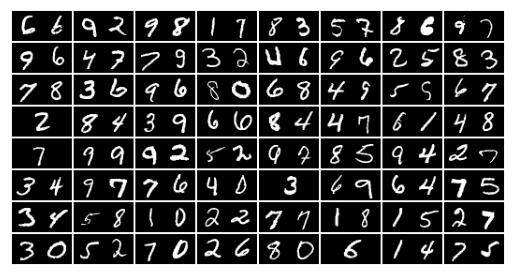

Saved preview: /kaggle/working/artifacts/mnist99_preview.png
Batch shape: torch.Size([64, 1, 32, 64])
Labels sample: [66, 92, 98, 17, 83, 57, 86, 97, 96, 47, 73, 32, 46, 96, 25, 83]


In [17]:
# Now we can show some of the new two-digit examples of the dataset

from dataset.mnist99_dataset import load_yaml_config, build_indices_by_digit, make_mnist99_sample

cfg = load_yaml_config("/kaggle/working/configs/dataset_conf.yaml")

mnist_root = "/kaggle/working/data/mnist"
mnist_train = MNIST(root=mnist_root, train=True, download=False, transform=transforms.ToTensor())

indices_by_digit = build_indices_by_digit(mnist_train)

rng = np.random.RandomState(cfg["seed"])

# 64 random labels
labels = [int(rng.randint(0, 100)) for _ in range(64)]
imgs = []
for lab in labels:
    img, y = make_mnist99_sample(lab, mnist_train, indices_by_digit, cfg, rng)
    imgs.append(img)

imgs = torch.stack(imgs, dim=0)  # (64,1,32,64)
grid = make_grid(imgs, nrow=8, padding=2, pad_value=1.0)

out_path = "/kaggle/working/artifacts/mnist99_preview.png"
save_image(grid, out_path)

img = Image.open("/kaggle/working/artifacts/mnist99_preview.png")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()
print("Saved preview:", out_path)
print("Batch shape:", imgs.shape)
print("Labels sample:", labels[:16])


## Dataset splitting (train/val/test)
> *I created a new parameter in dataset_conf.yaml (split.train_val) that define the split of train set in train set and validation set.*

> *If, for example, train_val: 0.9, the split will be:*
> - train: 54000
> - validation: 6000
> - test: 10000

> *I'll use the same seed as before also to shuffle the train set before splitting it.*

In [18]:
from torch.utils.data import Subset

mnist_root = "/kaggle/working/data/mnist"
mnist_full_train = MNIST(root=mnist_root, train=True, download=False, transform=transforms.ToTensor())
mnist_test = MNIST(root=mnist_root, train=False, download=False, transform=transforms.ToTensor())

cfg = __import__("dataset.mnist99_dataset", fromlist=["load_yaml_config"]).load_yaml_config("/kaggle/working/configs/dataset_conf.yaml")
seed = int(cfg["seed"])

# train/val split parameter
train_frac = float(cfg["split"]["train_val"])

N = len(mnist_full_train)
idx = np.arange(N)

# Shuffle train examples using seed, so it's deterministic
rng = np.random.RandomState(seed)
rng.shuffle(idx)

# split parameter represent the % value
N_train = int(N * train_frac)

# Split shuffled list
train_idx = idx[:N_train].tolist()
val_idx = idx[N_train:].tolist()

# Now i have a list of index for train images
# and one for val images.
# Create two sub-dataset
mnist_train = Subset(mnist_full_train, train_idx)
mnist_val = Subset(mnist_full_train, val_idx)

print("MNIST split:")
print("train:", len(mnist_train))
print("val  :", len(mnist_val))
print("test :", len(mnist_test))


MNIST split:
train: 54000
val  : 6000
test : 10000


## Custom Dataset Loader (in cache)
> *This script build the full mnist99 dataset (train/test/val) and saves it on the disk. This make easy to load the examples during the training phase.*

In [19]:
%%writefile /kaggle/working/dataset/build_cache.py
import os
import json
import argparse
from datetime import datetime
import numpy as np
import torch
from torch.utils.data import Subset
from torchvision.datasets import MNIST
from torchvision import transforms
from tqdm import tqdm
import sys
sys.path.append("/kaggle/working")

from dataset.mnist99_dataset import (load_yaml_config,build_indices_by_digit,make_mnist99_sample)

def _save_meta(path: str, meta: dict):
    with open(path, "w") as f:
        json.dump(meta, f, indent=2)

def build_split_cache(split: str, mnist_ds, cfg: dict, out_dir: str):    
    seed = int(cfg["seed"])

    # make it more random
    match split:
        case "train":
            split_offset = 0
        case "val":
            split_offset = 1
        case "test":
            split_offset = 2
            
    rng = np.random.RandomState(seed + split_offset)

    # index per-class dictionary
    indices_by_digit = build_indices_by_digit(mnist_ds)

    n_per_class = int(cfg["samples_per_class"][split])
    H, W = cfg["final_size"]

    # Create tensors of fixed dimension
    # (la so già perchè ho il parametro samples_per_class)
    total_samples = 100 * n_per_class
    images = torch.empty((total_samples, 1, H, W), dtype=torch.uint8)
    labels = torch.empty((total_samples,), dtype=torch.long)

    k = 0
    pbar = tqdm(total=total_samples, desc=f"Generating {split}", leave=True)

    # For each 0..99 label generate n=samples_per_class exmples
    for lab in range(100):
        for _ in range(n_per_class):
            img, l = make_mnist99_sample(lab, mnist_ds, indices_by_digit, cfg, rng)
            img_u8 = (img.clamp(0, 1) * 255.0).to(torch.uint8)

            images[k] = img_u8
            labels[k] = int(l)
            k += 1
            pbar.update(1)
    pbar.close()

    print("TOTAL_SAMPLES:",total_samples)
    print("LABELS_MIN:", labels.min())
    print("LABELS_MAX:", labels.max())

    # save tensors
    torch.save(images, os.path.join(out_dir, "images.pt"))
    torch.save(labels, os.path.join(out_dir, "labels.pt"))

    # Create a build file
    meta = {
        "split": split,
        "seed": seed,
        "seed_effective": seed + split_offset,
        "final_size": cfg["final_size"],
        "n_per_class": n_per_class,
        "total_samples": total_samples,
        "dtype_storage": cfg.get("dtype_storage", "uint8"),
        "compose": cfg["compose"],
        "note": "Sampling is with replacement (repetitions allowed).",
    }
    _save_meta(os.path.join(out_dir, "meta.json"), meta)

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--config", type=str, default="/kaggle/working/configs/dataset_conf.yaml")
    ap.add_argument("--split", type=str, choices=["train", "val", "test", "all"], default="all")
    ap.add_argument("--mnist_root", type=str, default="/kaggle/working/data/mnist")
    args = ap.parse_args()

    cfg = load_yaml_config(args.config)
    cache_root = cfg["cache"]["root"]

    base_train = MNIST(root=args.mnist_root, train=True, download=True, transform=transforms.ToTensor())
    base_test  = MNIST(root=args.mnist_root, train=False, download=True, transform=transforms.ToTensor())

    seed = int(cfg["seed"])
    train_frac = float(cfg["split"]["train_val"])

    N = len(base_train)
    idx = np.arange(N)
    rng = np.random.RandomState(seed)
    rng.shuffle(idx)

    N_train = int(N * train_frac)
    train_idx = idx[:N_train].tolist()
    val_idx = idx[N_train:].tolist()

    # Final Split
    mnist_train = Subset(base_train, train_idx)
    mnist_val = Subset(base_train, val_idx)
    mnist_test = base_test

    splits_to_build = ["train", "val", "test"] if args.split == "all" else [args.split]

    for sp in splits_to_build:
        out_dir = os.path.join(cache_root, sp)
        print(f"\nBuilding cache for split='{sp}' -> {out_dir}")
        ds = {"train": mnist_train, "val": mnist_val, "test": mnist_test}[sp]
        build_split_cache(sp, ds, cfg, out_dir)
        print(f"Done split='{sp}'")

if __name__ == "__main__":
    main()

Overwriting /kaggle/working/dataset/build_cache.py


### Execute mnist99 dataset build and save to cache
> *I'll leave --conf e --split as setted by default.*

In [20]:
%cd /kaggle/working
!mkdir data/mnist99
!mkdir data/mnist99/train
!mkdir data/mnist99/test
!mkdir data/mnist99/val


/kaggle/working
mkdir: cannot create directory ‘data/mnist99’: File exists
mkdir: cannot create directory ‘data/mnist99/train’: File exists
mkdir: cannot create directory ‘data/mnist99/test’: File exists
mkdir: cannot create directory ‘data/mnist99/val’: File exists


In [21]:
!python dataset/build_cache.py 


Building cache for split='train' -> /kaggle/working/data/mnist99/train
Generating train: 100%|███████████████| 200000/200000 [01:10<00:00, 2853.41it/s]
TOTAL_SAMPLES: 200000
LABELS_MIN: tensor(0)
LABELS_MAX: tensor(99)
Done split='train'

Building cache for split='val' -> /kaggle/working/data/mnist99/val
Generating val: 100%|███████████████████| 30000/30000 [00:10<00:00, 2874.40it/s]
TOTAL_SAMPLES: 30000
LABELS_MIN: tensor(0)
LABELS_MAX: tensor(99)
Done split='val'

Building cache for split='test' -> /kaggle/working/data/mnist99/test
Generating test: 100%|██████████████████| 30000/30000 [00:10<00:00, 2871.75it/s]
TOTAL_SAMPLES: 30000
LABELS_MIN: tensor(0)
LABELS_MAX: tensor(99)
Done split='test'


> Mnist99 dataset has been creates and saved to data/mnist99.

> Now we can continue with the training of the CNN.

# Defining the model
> *During this phase, different model architectures will be sperimented. The starting point is LeNet5 architecture, wich is defined as follow:*

**LeNet5:**
* **Input:** 1x32x32
* **Conv1:** 6 channels, 5x5 kernel, stride 1, padding 0 --> 6x28x28
* **Pool:** 2x2 kernel, stride 2, padding 0 --> 6x14x14
* **Conv2:** 16 channels, 5x5 kernel, stride 1, padding 0 --> 16x10x10
* **Pool:** 2x2 kernel, stride 2, padding 0 --> 16x5x5
* **Conv3:** 120 channels, 5x5 kernel, stride 1, padding 0 --> 120x1x1 (works like a FC)
* **FC1:** size 84
* **FC2:** size 10 (Output)(SoftMax)




In [2]:
!mkdir /kaggle/working/models
!mkdir /kaggle/working/utils
!mkdir /kaggle/working/checkpoints
!mkdir /kaggle/working/runs

## LeNet99_v1

> *If we simply try to use the original LeNet architecture and only change the input dimensions (1x32x64), we'll obtain a Flatten layer of size 1080, wich is too large and could reduce model performance.*

> *To resolve this problem, a first approach will be to **increase** the channel number for convolution layers and also to **add a new** convolution+pooling layer before the FC layers.*

**LeNet99_v1:**
* **Input:** 1x32x64
* **Conv1:** 16 channels, 5x5 kernel, stride 1, padding 0 --> 16x28x28
* **Pool:** 2x2 kernel, stride 2, padding 0 --> 16x14x30
* **Conv2:** 32 channels, 5x5 kernel, stride 1, padding 0 --> 32x10x26
* **Pool:** 2x2 kernel, stride 2, padding 0 --> 32x5x13
* **Conv3:** 64 channels, 3x3 kernel, stride 1, padding 1 --> 64x5x13
* **Pool (rectangular):** 1x2 kernel, stride 1x2, padding 0 --> 64x5x6
* **Flatten:** 64x5x6 -> 1920
* **FC1:** size 256
* **FC2:** size 128
* **FC3:** size 100 (Output)(SoftMax)


In [4]:
%%writefile /kaggle/working/models/lenet99_v1.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class LeNet99(nn.Module):
    def __init__(self, num_classes=100, dropout_p=0.1):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)    # pad=1 to mantain same W,H

        # Pooling layers
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.pool_rect = nn.AvgPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0)  # 1x2 rectangular pooling

        # Fully-Connected layers
        # Dimensions after convs/pools is: 64 x 5 x 6 = 1920
        self.fc1 = nn.Linear(64 * 5 * 6, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        # Dropout layer to reduce overfitting
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        # We'll use ReLu instead of tanh as activation function
        
        # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv1(x)))

        # Conv2 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Conv3 + ReLU
        x = F.relu(self.conv3(x))
        
        # Pool rectangular
        x = self.pool_rect(x)

        # Flatten (B,64,5,6) -> (B,1920)
        x = x.view(x.size(0), -1)

        # Fully-connected
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)  # (B,100)

        return x


Overwriting /kaggle/working/models/lenet99_v1.py


# Training
> *The same structure as the dataset creator will be used, so we'll have a configuration file and a trainings script that reads the configuration.*

> *training_conf.yaml contains all the configurable params for the model training*

In [6]:
%%writefile /kaggle/working/configs/training_conf.yaml
run:
  name: "lenet99_adam_lr1e-3"

train:
  epochs: 10
  batch_size: 256
  lr: 0.001
  num_workers: 2
  print_every: 300
  use_amp: true
  seed: 42

paths:
  dataset_conf: "/kaggle/working/configs/dataset_conf.yaml"
  ckpt_dir: "/kaggle/working/checkpoints"
  runs_dir: "/kaggle/working/runs"

resume:
  path: ""       # populate only for resume training with the *_last.pt


Overwriting /kaggle/working/configs/training_conf.yaml


In [2]:
%%writefile /kaggle/working/train_lenet99.py
import os
import time
import random
import yaml

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from dataset.mnist99_dataset import load_yaml_config, MNIST99Dataset
from models.lenet99_v1 import LeNet99


# CONFIG LOADING
TRAINING_CFG_PATH = "/kaggle/working/configs/training_conf.yaml"


def load_training_config(path: str) -> dict:
    with open(path, "r") as f:
        cfg = yaml.safe_load(f)
    cfg.setdefault("run", {})
    cfg.setdefault("train", {})
    cfg.setdefault("paths", {})
    cfg.setdefault("resume", {})
    return cfg


def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def save_ckpt(path, model, optimizer, epoch, best_acc, run_name, cfg):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "epoch": epoch,
        "best_val_acc": best_acc,
        "run_name": run_name,
        "training_cfg": cfg,
    }, path)


@torch.no_grad()
def evaluate(net, valloader, criterion, device):
    net.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in valloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = net(images)
        loss = criterion(outputs, labels)

        bs = images.size(0)
        total_loss += loss.item() * bs
        _, predicted = torch.max(outputs, 1)
        total += bs
        correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total


def main():
    cfg = load_training_config(TRAINING_CFG_PATH)

    # read params
    RUN_NAME = cfg["run"].get("name", "lenet99_run")
    EPOCHS = int(cfg["train"].get("epochs", 10))
    BATCH_SIZE = int(cfg["train"].get("batch_size", 256))
    LR = float(cfg["train"].get("lr", 1e-3))
    NUM_WORKERS = int(cfg["train"].get("num_workers", 2))
    PRINT_EVERY = int(cfg["train"].get("print_every", 50))
    USE_AMP = bool(cfg["train"].get("use_amp", True))
    SEED = int(cfg["train"].get("seed", 42))

    DATASET_CONF_PATH = cfg["paths"].get("dataset_conf", "/kaggle/working/configs/dataset_conf.yaml")
    CKPT_DIR = cfg["paths"].get("ckpt_dir", "/kaggle/working/checkpoints")
    RUNS_DIR = cfg["paths"].get("runs_dir", "/kaggle/working/runs")

    RESUME_PATH = cfg["resume"].get("path", "")

    # setup
    os.makedirs(CKPT_DIR, exist_ok=True)
    os.makedirs(RUNS_DIR, exist_ok=True)
    set_seed(SEED)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # dataset load
    ds_cfg = load_yaml_config(DATASET_CONF_PATH)
    trainset = MNIST99Dataset("train", ds_cfg)
    valset = MNIST99Dataset("val", ds_cfg)

    trainloader = DataLoader(
        trainset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
    )
    valloader = DataLoader(
        valset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    # model/optimizer
    net = LeNet99(num_classes=100, dropout_p=0.1).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=LR)

    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type == "cuda"))

    # logs for TensorBoard
    logdir = os.path.join(RUNS_DIR, RUN_NAME)
    writer = SummaryWriter(log_dir=logdir)
    print("TensorBoard logdir:", logdir)

    # resume (if path not empty)
    start_epoch = 0
    best_val_acc = 0.0
    if RESUME_PATH:
        ckpt = torch.load(RESUME_PATH, map_location=device)
        net.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt.get("epoch", 0)
        best_val_acc = ckpt.get("best_val_acc", 0.0)
        print(f"Resumed from {RESUME_PATH} (start_epoch={start_epoch}, best_val_acc={best_val_acc:.4f})")

    # train loop
    for epoch in range(start_epoch, EPOCHS):
        t0 = time.time()

        net.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for i, (inputs, labels) in enumerate(trainloader, start=1):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type == "cuda")):
                outputs = net(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = inputs.size(0)
            running_loss += loss.item() * bs
            _, preds = torch.max(outputs, 1)
            running_total += bs
            running_correct += (preds == labels).sum().item()

            if i % PRINT_EVERY == 0:
                avg_loss = running_loss / running_total
                avg_acc = running_correct / running_total
                print(f"[Epoch {epoch+1}/{EPOCHS}] step {i}/{len(trainloader)} "
                      f"loss: {avg_loss:.4f} acc: {avg_acc:.4f}")

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        val_loss, val_acc = evaluate(net, valloader, criterion, device)

        dt = time.time() - t0
        lr_now = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
              f"lr {lr_now:.2e} | time {dt:.1f}s")

        # values for TensorBoard
        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("acc/train", train_acc, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)
        writer.add_scalar("acc/val", val_acc, epoch)
        writer.add_scalar("lr", lr_now, epoch)

        # checkpoint last
        last_path = os.path.join(CKPT_DIR, "lenet99_last.pt")
        save_ckpt(last_path, net, optimizer, epoch + 1, best_val_acc, RUN_NAME, cfg)

        # checkpoint best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_path = os.path.join(CKPT_DIR, "lenet99_best.pt")
            save_ckpt(best_path, net, optimizer, epoch + 1, best_val_acc, RUN_NAME, cfg)
            print(f"  -> New BEST saved: {best_path} (best_val_acc={best_val_acc:.4f})")

    writer.close()
    print("Done. Best val acc:", best_val_acc)


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/train_lenet99.py


In [3]:
!python /kaggle/working/train_lenet99.py

2026-03-04 10:07:11.856969: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772618832.258862     116 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772618832.382031     116 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772618833.352992     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772618833.353045     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772618833.353049     116 computation_placer.cc:177] computation placer alr

# TensorBoard
> *After various tries implementing tensorboard in kaggle, i discovered that it's not supported in this environment, because kaggle cannot expose ports.*

> *One possibile solution could be to **export** the results of the training phase and import them in Colab (or my PC), where tensorboard can work well.*


In [3]:
!zip -r runs.zip runs

  adding: runs/ (stored 0%)
  adding: runs/A2_dropout0/ (stored 0%)
  adding: runs/A2_dropout0/events.out.tfevents.1772621473.010b0b508e9f.1378.0 (deflated 59%)
  adding: runs/A0_base_adam/ (stored 0%)
  adding: runs/A0_base_adam/events.out.tfevents.1772707298.5ea589f6943c.111.0 (deflated 64%)
  adding: runs/A0_base_adam/events.out.tfevents.1772621299.010b0b508e9f.901.0 (deflated 59%)
  adding: runs/A1_sgd_momentum/ (stored 0%)
  adding: runs/A1_sgd_momentum/events.out.tfevents.1772621386.010b0b508e9f.1147.0 (deflated 59%)
  adding: runs/A3_poolmax/ (stored 0%)
  adding: runs/A3_poolmax/events.out.tfevents.1772621561.010b0b508e9f.1601.0 (deflated 59%)
  adding: runs/lenet99_adam_lr1e-3/ (stored 0%)
  adding: runs/lenet99_adam_lr1e-3/events.out.tfevents.1772099369.18f31da9251a.393.0 (deflated 9%)
  adding: runs/lenet99_adam_lr1e-3/events.out.tfevents.1772618853.010b0b508e9f.116.0 (deflated 59%)
  adding: runs/lenet99_adam_lr1e-3/events.out.tfevents.1772099439.18f31da9251a.548.0 (deflate

> After completing this step, download "runs.zip" and open the Colab Notebook: [TwoDigitClassifier (TensorBoard).ipynb](https://colab.research.google.com/drive/1zC6tYKHBNXDp3eWyH95o9FL5Qb9nZaA5?usp=sharing)


In [46]:
!rm runs.zip

# Evaluation
> *eval_lenet99.py loads a checkpoint and the test set and evaluates the metrics. These will be saved in artifacts/eval_min*

> In this step, we will calculate:
> * loss
> * accuracy
> * group_accuracy
> * confusion_matrix (with top 10 confusion)
> * error_grid
> * number of wrong prediction over the total 

In [25]:
%%writefile /kaggle/working/eval_lenet99.py
import argparse
import json
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from dataset.mnist99_dataset import load_yaml_config, MNIST99Dataset
from models.lenet99_v1 import LeNet99

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

from torchvision.utils import make_grid

from IPython.display import Image, display


@torch.no_grad()
def evaluate(model, loader, device, criterion):
    '''
    model: network loaded by the ckeckpoint
    loader: dataLoader of test set
    device: cuda/cpu
    criterion: loss (CrossEntropy)

    returns: avg loss, avg accuracy, all target labels, all predicted labels
    '''
    
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    # all label list
    all_targets = []
    
    # all predicted labels list
    all_preds = []

    # x: images batch
    # y: labels batch
    for x, y in loader:

        # move tensors to device
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # forward and calculate loss
        logits = model(x)
        loss = criterion(logits, y)

        # calculate class prediction
        preds = torch.argmax(logits, dim=1)

        # update scores
        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        # add all the labels
        all_targets.append(y.detach().cpu())
        all_preds.append(preds.detach().cpu())

    all_targets = torch.cat(all_targets).numpy()
    all_preds = torch.cat(all_preds).numpy()

    return total_loss / total, total_correct / total, all_targets, all_preds

def group_accuracy(targets, preds):
    '''
    Evaluates the accuracy on the classes 0-9 vs 10-99
    '''
    targets = targets.astype(int)
    preds = preds.astype(int)

    mask_single = (targets >= 0) & (targets <= 9)
    mask_double = (targets >= 10) & (targets <= 99)

    acc_0_9 = float((preds[mask_single] == targets[mask_single]).mean()) if mask_single.any() else None
    acc_10_99 = float((preds[mask_double] == targets[mask_double]).mean()) if mask_double.any() else None

    return {
        "acc_0_9": acc_0_9,
        "n_0_9": int(mask_single.sum()),
        "acc_10_99": acc_10_99,
        "n_10_99": int(mask_double.sum()),
    }

def main():
    '''
    ARGUMENTS:
    --training_conf
    --ckpt
    --split
    --save_dir
    --max_wrong
    '''
    parser = argparse.ArgumentParser()
    parser.add_argument("--training_conf", type=str, default="configs/training_conf.yaml")
    parser.add_argument("--ckpt", type=str, default="checkpoints/lenet99_best.pt")
    parser.add_argument("--split", type=str, default="test", choices=["train", "val", "test"])
    parser.add_argument("--save_dir", type=str, default="artifacts/eval_min")
    parser.add_argument("--max_wrong", type=int, default=64)
    args = parser.parse_args()

    cfg = load_yaml_config(args.training_conf)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # load dataset and dataset config
    train_cfg = load_yaml_config(args.training_conf)
    bs = int(train_cfg["train"].get("batch_size", 256))
    nw = int(train_cfg["train"].get("num_workers", 2))
    dataset_conf_path = train_cfg["paths"]["dataset_conf"]
    dataset_cfg = load_yaml_config(dataset_conf_path)

    ds = MNIST99Dataset(split=args.split, cfg=dataset_cfg)
    loader = DataLoader(
        ds,
        batch_size=bs,
        shuffle=False,
        num_workers=nw,
        pin_memory=(device.type == "cuda"),
    )

    # load model
    model = LeNet99(num_classes=100).to(device)

    # load checkpoint
    ckpt = torch.load(args.ckpt, map_location="cpu")

    if isinstance(ckpt, dict) and "model_state" in ckpt:
        model.load_state_dict(ckpt["model_state"])
    else:
        model.load_state_dict(ckpt)

    # define the loss
    criterion = nn.CrossEntropyLoss()


    
    ############## EVALUATE ###############
    test_loss, test_acc, targets, preds = evaluate(model, loader, device, criterion)

    # group accuracy (0-9 vs 10-99)
    grp = group_accuracy(targets, preds)

    save_dir = Path(args.save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    metrics = {
        "split": args.split,
        "ckpt": args.ckpt,
        "loss": float(test_loss),
        "accuracy": float(test_acc),
        "num_samples": len(ds),
        "group_accuracy": grp,
        "num_wrong": int((preds != targets).sum()),
    }

    with open(save_dir / f"metrics_{args.split}.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(json.dumps(metrics, indent=2))
    print(f"Saved metrics to: {save_dir / f'metrics_{args.split}.json'}")



    ################## CONFUSION MATRIX #####################
    # produce 100x100 confusion matrix
    cm = confusion_matrix(targets, preds, labels=list(range(100)))

    # top 10 confusions
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    flat = cm_no_diag.flatten()
    topk_idx = flat.argsort()[::-1]
    top10 = []
    for idx in topk_idx:
        count = flat[idx]
        if count == 0:
            break
        t = idx // 100
        p = idx % 100
        top10.append((t, p, int(count)))
        if len(top10) == 10:
            break

    print("\nTop-10 confusions (True -> Pred : count)")
    for t, p, c in top10:
        print(f"{t:02d} -> {p:02d} : {c}")

    # save as png
    cm_path = save_dir / f"confusion_{args.split}.png"
    plt.figure(figsize=(14, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix ({args.split})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(cm_path, dpi=200)
    plt.close()

    # display image inline
    display(Image(filename=str(cm_path)))



    ################### ERROR GRID ######################
    # create error grid (show where the model makes mistakes)
    wrong_idx = np.where(preds != targets)[0][:args.max_wrong]

    if len(wrong_idx) > 0:
        nrow = 8
        ncol = int(np.ceil(len(wrong_idx) / nrow))

        fig, axes = plt.subplots(ncol, nrow, figsize=(2.2 * nrow, 2.2 * ncol))
        axes = np.atleast_2d(axes)

        for k, idx in enumerate(wrong_idx):
            r = k // nrow
            c = k % nrow

            img, true_y = ds[idx]
            pred_y = int(preds[idx])

            ax = axes[r, c]
            ax.imshow(img.squeeze(0).numpy(), cmap="gray")
            ax.set_title(f"T={int(true_y):02d} P={pred_y:02d}", fontsize=10)
            ax.axis("off")

        for k in range(len(wrong_idx), nrow * ncol):
            r = k // nrow
            c = k % nrow
            axes[r, c].axis("off")

        # save as png
        wrong_path = save_dir / f"wrong_grid_{args.split}.png"
        plt.tight_layout()
        plt.savefig(wrong_path, dpi=200)
        plt.close(fig)

        # display image inline
        display(Image(filename=str(wrong_path)))
    else:
        wrong_path = None




if __name__ == "__main__":
    main()


Overwriting /kaggle/working/eval_lenet99.py


{
  "split": "test",
  "ckpt": "checkpoints/lenet99_best.pt",
  "loss": 0.05694939790219068,
  "accuracy": 0.9848333333333333,
  "num_samples": 30000,
  "group_accuracy": {
    "acc_0_9": 0.9893333333333333,
    "n_0_9": 3000,
    "acc_10_99": 0.9843333333333333,
    "n_10_99": 27000
  },
  "num_wrong": 455
}
Saved metrics to: artifacts/eval_min/metrics_test.json

Top-10 confusions (True -> Pred : count)
35 -> 33 : 5
14 -> 19 : 5
92 -> 42 : 5
94 -> 99 : 5
89 -> 83 : 5
43 -> 93 : 4
29 -> 24 : 4
04 -> 09 : 4
25 -> 23 : 4
15 -> 13 : 4


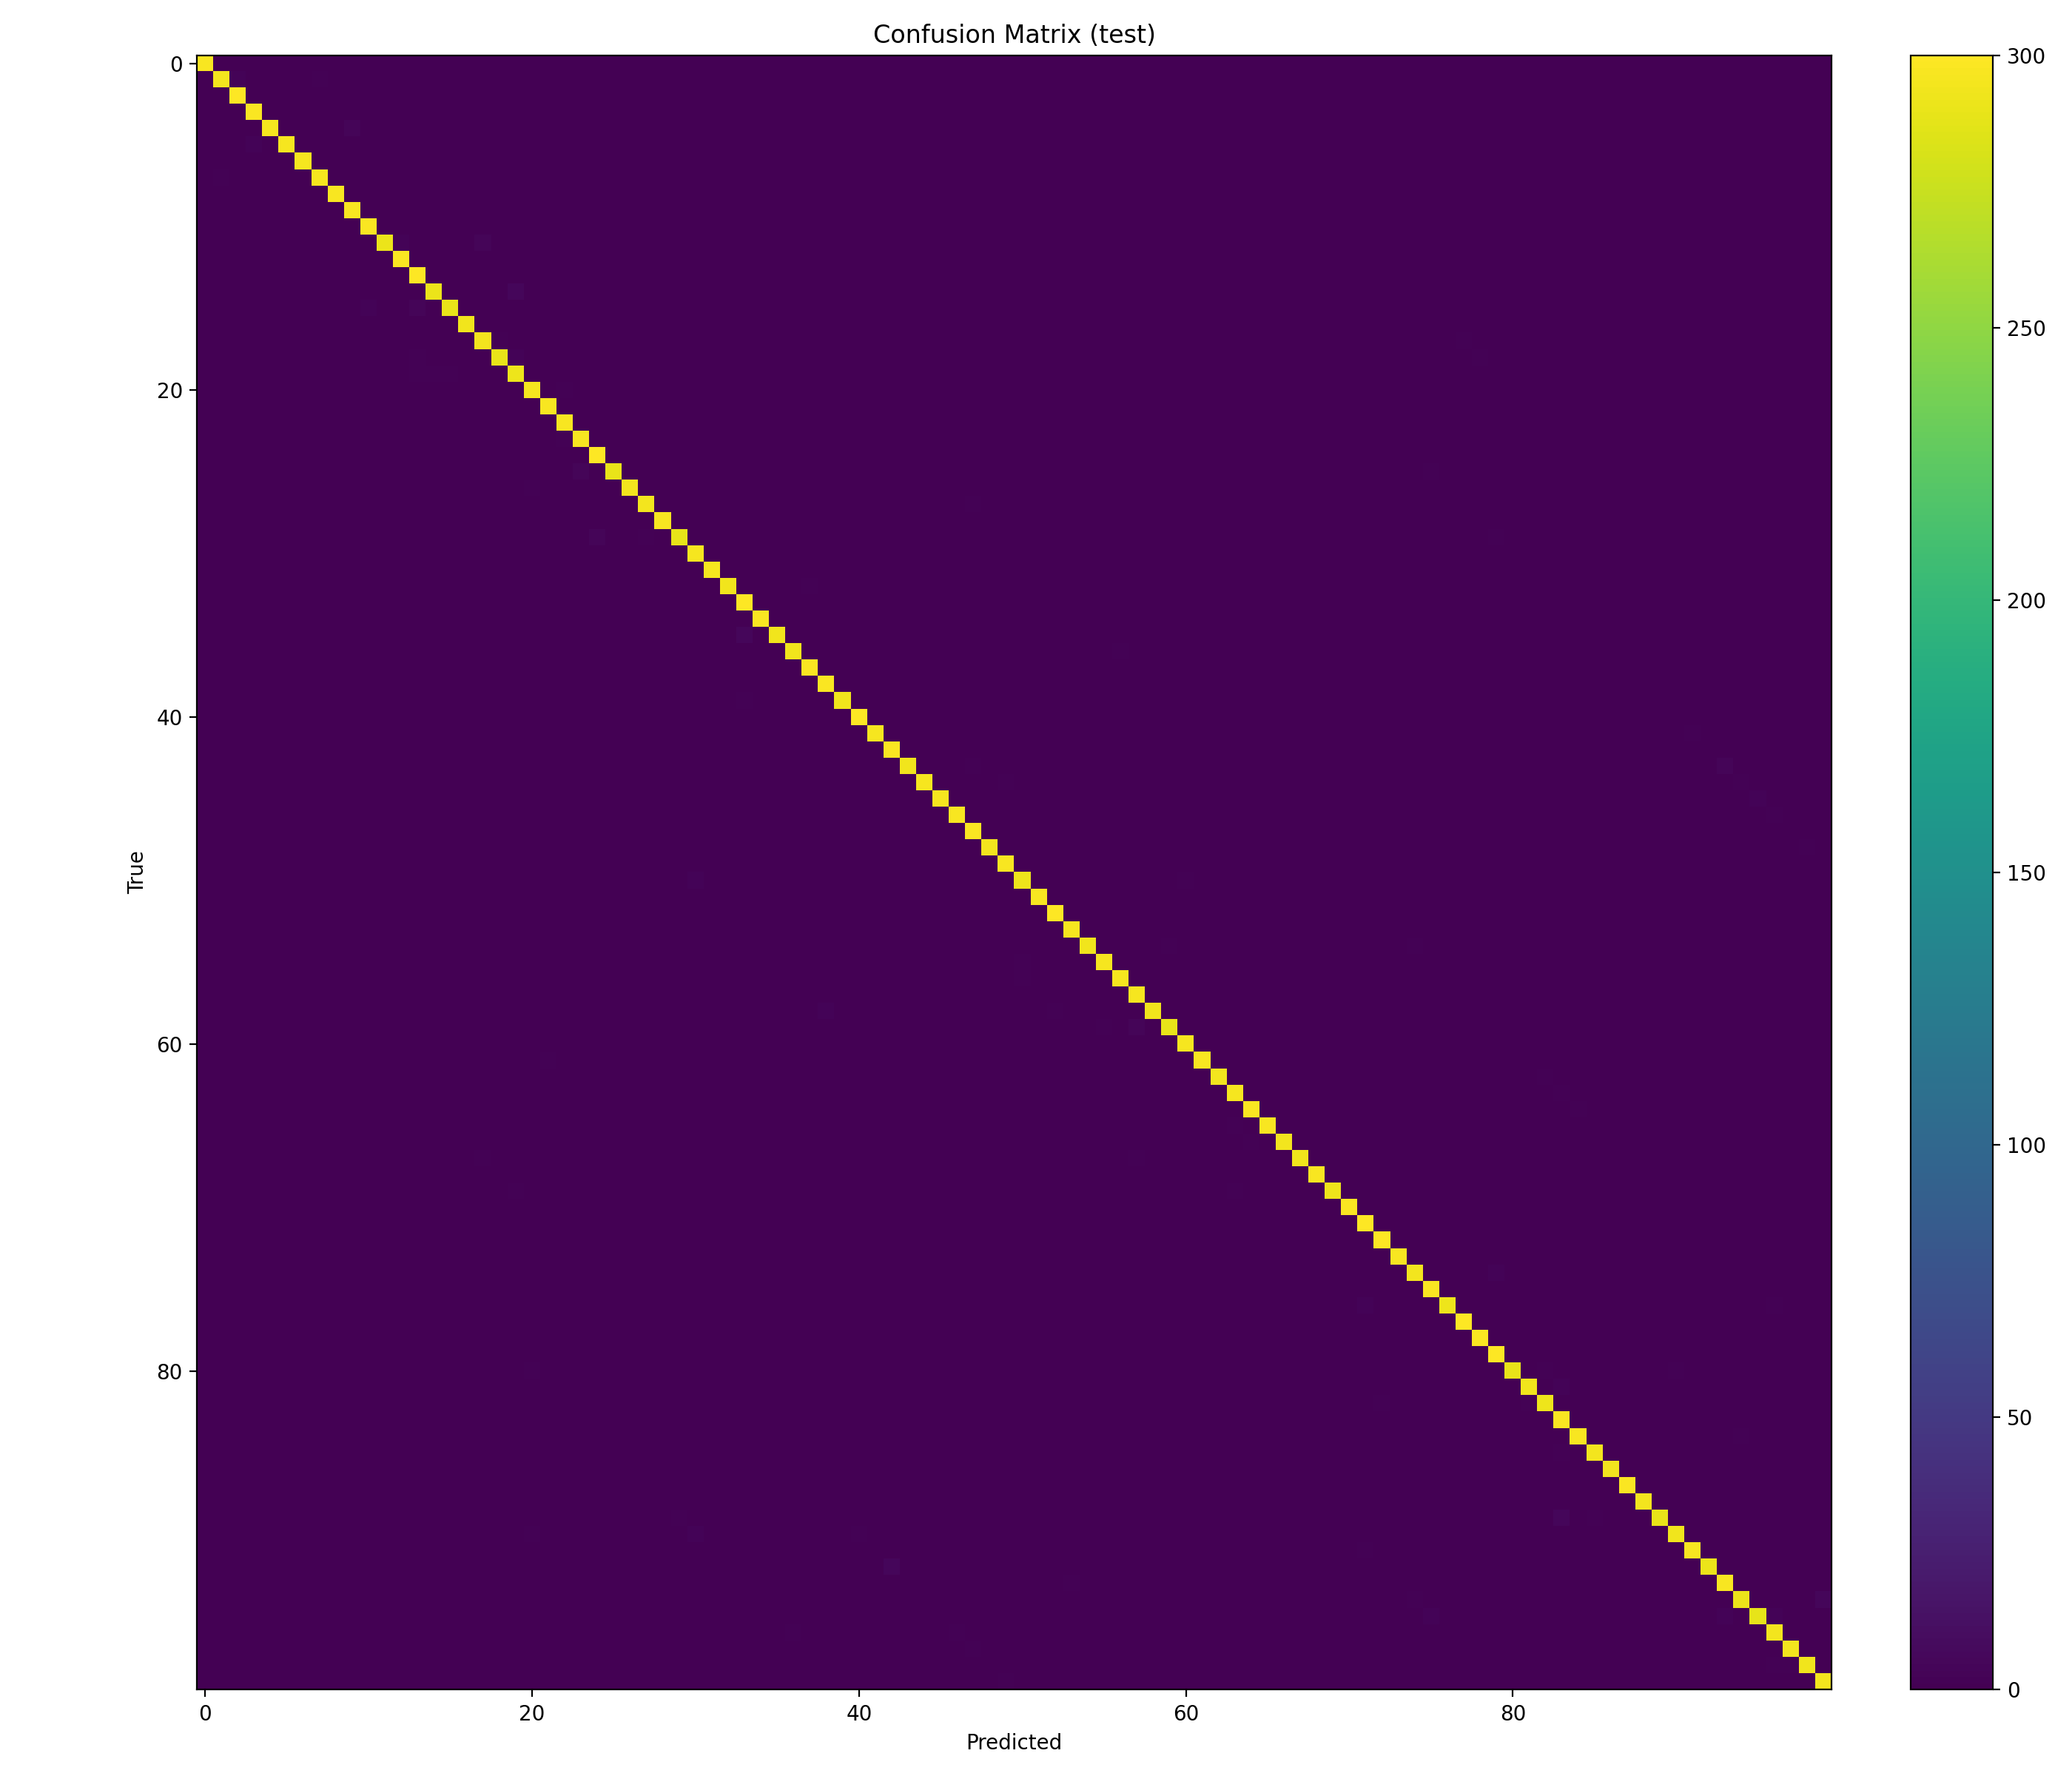

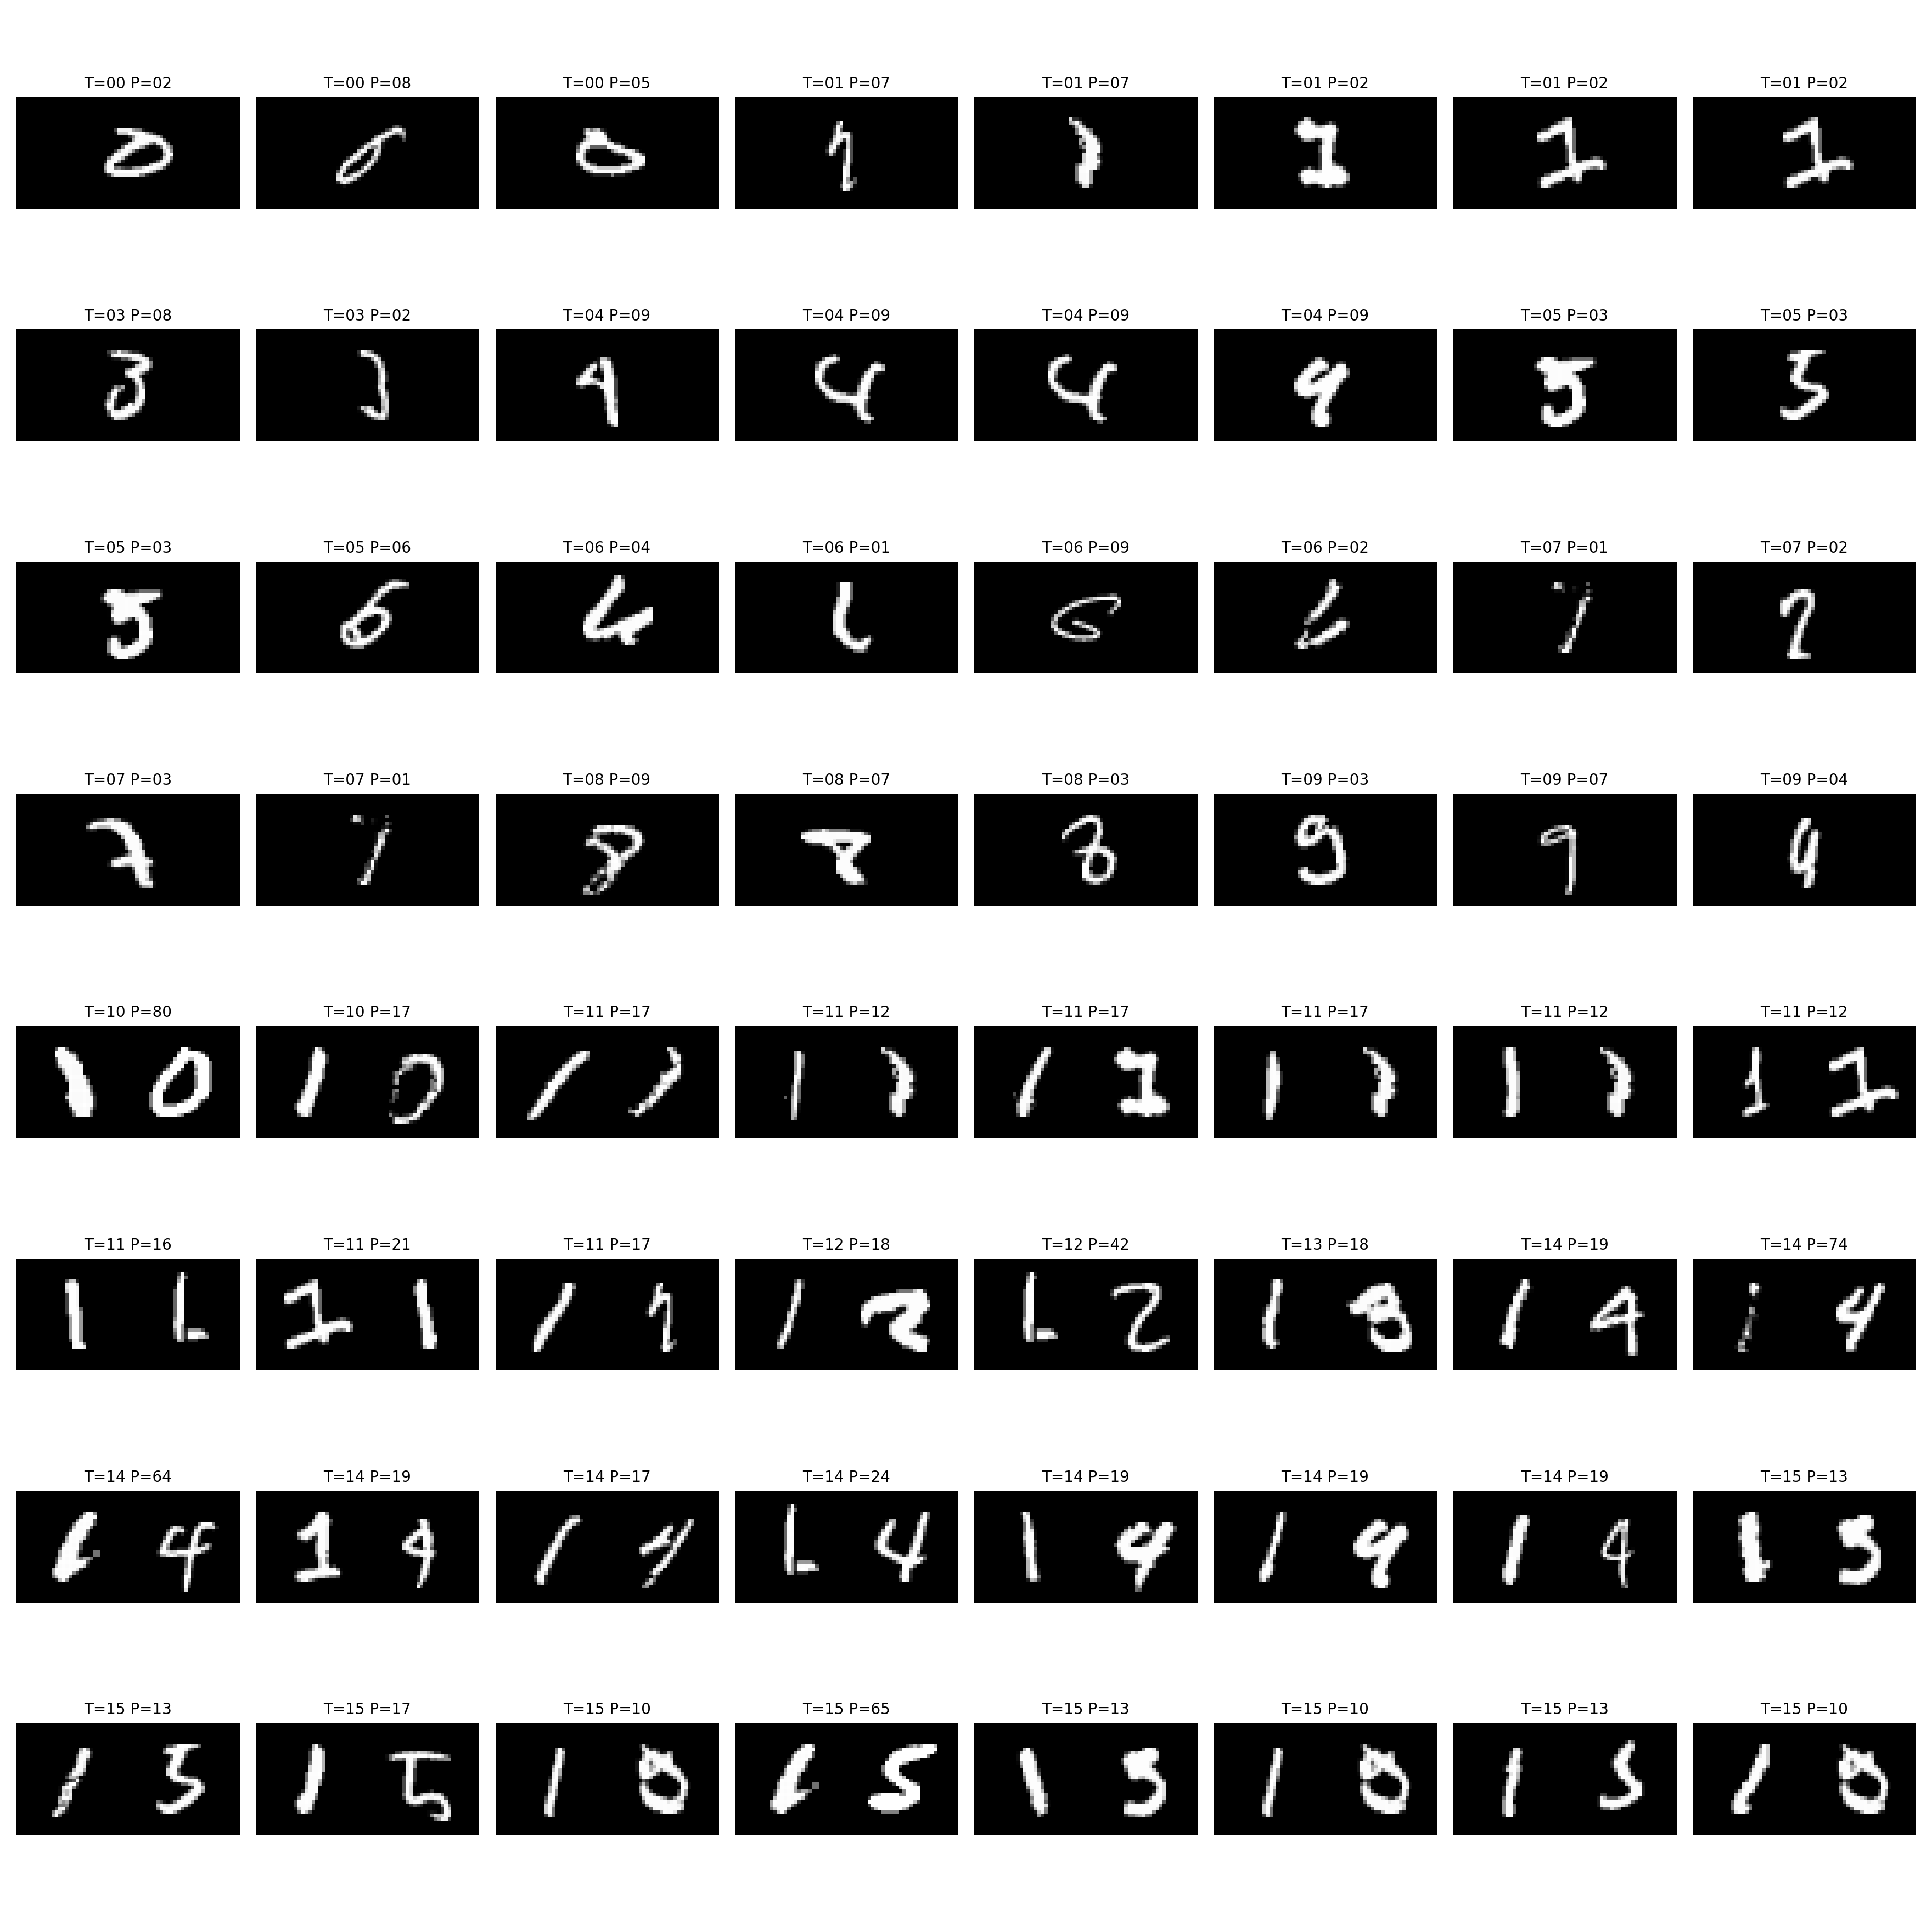

<Figure size 640x480 with 0 Axes>

In [26]:
%run /kaggle/working/eval_lenet99.py

# Ablation Tests

In [11]:
%%writefile /kaggle/working/models/lenet99_v1_ablation.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class LeNet99(nn.Module):
    """
    Added for ablation:
      - dropout_p: dropout probability in FC layers
      - final_pool: {"avg", "max", "none"} rectangular pooling (1x2) after conv3

    """
    def __init__(self, num_classes=100, dropout_p=0.1, final_pool="avg"):
        super().__init__()

        final_pool = (final_pool or "avg").lower()
        if final_pool not in ["avg", "max", "none"]:
            raise ValueError(f"final_pool must be one of ['avg','max','none'], got: {final_pool}")

        self.final_pool_type = final_pool

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # pad=1 to mantain same W,H

        # Pooling layers
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)

        # 1x2 rectangular pooling
        if final_pool == "avg":
            self.pool_rect = nn.AvgPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0)
            flat_dim = 64 * 5 * 6   # after pool_rect: W 12 -> 6
        elif final_pool == "max":
            self.pool_rect = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0)
            flat_dim = 64 * 5 * 6
        else:  # none
            self.pool_rect = nn.Identity()
            flat_dim = 64 * 5 * 12  # without pool_rect W remain 12

        # Fully-Connected layers
        self.fc1 = nn.Linear(flat_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        # Dropout layer to reduce overfitting
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv1(x)))

        # Conv2 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Conv3 + ReLU
        x = F.relu(self.conv3(x))

        # Pool rectangular
        x = self.pool_rect(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully-connected
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

Writing /kaggle/working/models/lenet99_v1_ablation.py


In [13]:
%%writefile /kaggle/working/train_lenet99_ablation.py
import os
import time
import random
import argparse
import yaml

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from dataset.mnist99_dataset import load_yaml_config, MNIST99Dataset

from models.lenet99_v1_ablation import LeNet99  # ablation variation of the model


def load_training_config(path: str) -> dict:
    with open(path, "r") as f:
        cfg = yaml.safe_load(f)

    # dynamic config loader
    cfg = cfg or {}
    cfg.setdefault("run", {})
    cfg.setdefault("train", {})
    cfg.setdefault("paths", {})
    cfg.setdefault("resume", {})
    cfg.setdefault("optimizer", {})
    cfg.setdefault("model", {})
    return cfg


def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def make_optimizer(cfg: dict, net: nn.Module, lr: float):
    # set optimizer based on config (for now choose between Adam and SGD)
    opt_cfg = cfg.get("optimizer", {}) or {}
    name = (opt_cfg.get("name", "adam") or "adam").lower()
    wd = float(opt_cfg.get("weight_decay", 0.0) or 0.0)

    if name == "adam":
        return torch.optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
    elif name == "sgd":
        mom = float(opt_cfg.get("momentum", 0.9) or 0.9)
        return torch.optim.SGD(net.parameters(), lr=lr, momentum=mom, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer.name='{name}' (use 'adam' or 'sgd').")


def save_ckpt(path, model, optimizer, scaler, epoch, best_acc, run_name, cfg):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "epoch": epoch,
        "best_val_acc": best_acc,
        "run_name": run_name,
        "training_cfg": cfg,
    }, path)

@torch.no_grad()

def evaluate(net, valloader, criterion, device):
    net.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in valloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = net(images)
        loss = criterion(outputs, labels)

        bs = images.size(0)
        total_loss += loss.item() * bs
        _, predicted = torch.max(outputs, 1)
        total += bs
        correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total


def main():
    parser = argparse.ArgumentParser()

    # add config via argument
    parser.add_argument(
        "--config",
        default="/kaggle/working/configs/training_conf.yaml",
        help="Path to training yaml config."
    )
    args = parser.parse_args()

    cfg = load_training_config(args.config)

    # read params
    RUN_NAME = cfg["run"].get("name", "lenet99_run")

    EPOCHS = int(cfg["train"].get("epochs", 10))
    BATCH_SIZE = int(cfg["train"].get("batch_size", 256))
    LR = float(cfg["train"].get("lr", 1e-3))
    NUM_WORKERS = int(cfg["train"].get("num_workers", 2))
    PRINT_EVERY = int(cfg["train"].get("print_every", 50))
    USE_AMP = bool(cfg["train"].get("use_amp", True))
    SEED = int(cfg["train"].get("seed", 42))

    DATASET_CONF_PATH = cfg["paths"].get("dataset_conf", "/kaggle/working/configs/dataset_conf.yaml")
    CKPT_ROOT = cfg["paths"].get("ckpt_dir", "/kaggle/working/checkpoints")
    RUNS_DIR = cfg["paths"].get("runs_dir", "/kaggle/working/runs")

    RESUME_PATH = cfg["resume"].get("path", "")

    # per-run dirs
    ckpt_dir = os.path.join(CKPT_ROOT, RUN_NAME)
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(RUNS_DIR, exist_ok=True)

    set_seed(SEED)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    print("Run name:", RUN_NAME)
    print("Config:", args.config)
    print("Checkpoints dir:", ckpt_dir)

    # dataset load
    ds_cfg = load_yaml_config(DATASET_CONF_PATH)
    trainset = MNIST99Dataset("train", ds_cfg)
    valset = MNIST99Dataset("val", ds_cfg)

    trainloader = DataLoader(
        trainset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
    )
    valloader = DataLoader(
        valset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    # model params (now dynamics for ablation)
    model_cfg = cfg.get("model", {}) or {}
    dropout_p = float(model_cfg.get("dropout", 0.1) or 0.0)
    final_pool = model_cfg.get("final_pool", "avg") # added for ablation

    net = LeNet99(num_classes=100, dropout_p=dropout_p, final_pool=final_pool).to(device)

    criterion = nn.CrossEntropyLoss()

    # dynamic optimizer for ablation
    optimizer = make_optimizer(cfg, net, LR)

    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type == "cuda"))

    # logs for TensorBoard
    logdir = os.path.join(RUNS_DIR, RUN_NAME)
    writer = SummaryWriter(log_dir=logdir)
    print("TensorBoard logdir:", logdir)

    # resume (if path not empty)
    start_epoch = 0
    best_val_acc = 0.0
    if RESUME_PATH:
        ckpt = torch.load(RESUME_PATH, map_location=device)
        net.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        if ckpt.get("scaler_state") is not None:
            scaler.load_state_dict(ckpt["scaler_state"])

        start_epoch = int(ckpt.get("epoch", 0))
        best_val_acc = float(ckpt.get("best_val_acc", 0.0))
        print(f"Resumed from {RESUME_PATH} (start_epoch={start_epoch}, best_val_acc={best_val_acc:.4f})")

    # train loop
    for epoch in range(start_epoch, EPOCHS):
        t0 = time.time()

        net.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for i, (inputs, labels) in enumerate(trainloader, start=1):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type == "cuda")):
                outputs = net(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = inputs.size(0)
            running_loss += loss.item() * bs
            _, preds = torch.max(outputs, 1)
            running_total += bs
            running_correct += (preds == labels).sum().item()

            if i % PRINT_EVERY == 0:
                avg_loss = running_loss / running_total
                avg_acc = running_correct / running_total
                print(f"[Epoch {epoch+1}/{EPOCHS}] step {i}/{len(trainloader)} "
                      f"loss: {avg_loss:.4f} acc: {avg_acc:.4f}")

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        val_loss, val_acc = evaluate(net, valloader, criterion, device)

        dt = time.time() - t0
        lr_now = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
              f"lr {lr_now:.2e} | time {dt:.1f}s")

        # values for TensorBoard
        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("acc/train", train_acc, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)
        writer.add_scalar("acc/val", val_acc, epoch)
        writer.add_scalar("lr", lr_now, epoch)

        # checkpoint last (epoch+1 = next epoch)
        last_path = os.path.join(ckpt_dir, "last.pt")
        save_ckpt(last_path, net, optimizer, scaler, epoch + 1, best_val_acc, RUN_NAME, cfg)

        # checkpoint best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_path = os.path.join(ckpt_dir, "best.pt")
            save_ckpt(best_path, net, optimizer, scaler, epoch + 1, best_val_acc, RUN_NAME, cfg)
            print(f"  -> New BEST saved: {best_path} (best_val_acc={best_val_acc:.4f})")

    writer.close()
    print("Done. Best val acc:", best_val_acc)


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/train_lenet99_ablation.py


In [38]:
%%writefile /kaggle/working/eval_lenet99_ablation.py
import argparse
import json
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from dataset.mnist99_dataset import load_yaml_config, MNIST99Dataset
from models.lenet99_v1_ablation import LeNet99  # ablation variation of the model

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

from torchvision.utils import make_grid

from IPython.display import Image, display


@torch.no_grad()
def evaluate(model, loader, device, criterion):
    '''
    model: network loaded by the ckeckpoint
    loader: dataLoader of test set
    device: cuda/cpu
    criterion: loss (CrossEntropy)

    returns: avg loss, avg accuracy, all target labels, all predicted labels
    '''
    
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    # all label list
    all_targets = []
    
    # all predicted labels list
    all_preds = []

    # x: images batch
    # y: labels batch
    for x, y in loader:

        # move tensors to device
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # forward and calculate loss
        logits = model(x)
        loss = criterion(logits, y)

        # calculate class prediction
        preds = torch.argmax(logits, dim=1)

        # update scores
        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        # add all the labels
        all_targets.append(y.detach().cpu())
        all_preds.append(preds.detach().cpu())

    all_targets = torch.cat(all_targets).numpy()
    all_preds = torch.cat(all_preds).numpy()

    return total_loss / total, total_correct / total, all_targets, all_preds

def group_accuracy(targets, preds):
    '''
    Evaluates the accuracy on the classes 0-9 vs 10-99
    '''
    targets = targets.astype(int)
    preds = preds.astype(int)

    mask_single = (targets >= 0) & (targets <= 9)
    mask_double = (targets >= 10) & (targets <= 99)

    acc_0_9 = float((preds[mask_single] == targets[mask_single]).mean()) if mask_single.any() else None
    acc_10_99 = float((preds[mask_double] == targets[mask_double]).mean()) if mask_double.any() else None

    return {
        "acc_0_9": acc_0_9,
        "n_0_9": int(mask_single.sum()),
        "acc_10_99": acc_10_99,
        "n_10_99": int(mask_double.sum()),
    }

def main():
    '''
    ARGUMENTS:
    --training_conf
    --ckpt
    --split
    --save_dir
    --max_wrong
    '''
    parser = argparse.ArgumentParser()
    parser.add_argument("--training_conf", type=str, default="configs/training_conf.yaml")
    parser.add_argument("--ckpt", type=str, default="checkpoints/lenet99_best.pt")
    parser.add_argument("--split", type=str, default="test", choices=["train", "val", "test"])
    parser.add_argument("--save_dir", type=str, default="artifacts/eval_min")
    parser.add_argument("--max_wrong", type=int, default=64)
    args = parser.parse_args()

    cfg = load_yaml_config(args.training_conf)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # load dataset and dataset config
    train_cfg = load_yaml_config(args.training_conf)
    run_name = train_cfg.get("run", {}).get("name", "unknown_run")
    bs = int(train_cfg["train"].get("batch_size", 256))
    nw = int(train_cfg["train"].get("num_workers", 2))
    dataset_conf_path = train_cfg["paths"]["dataset_conf"]
    dataset_cfg = load_yaml_config(dataset_conf_path)

    ds = MNIST99Dataset(split=args.split, cfg=dataset_cfg)
    loader = DataLoader(
        ds,
        batch_size=bs,
        shuffle=False,
        num_workers=nw,
        pin_memory=(device.type == "cuda"),
    )

    # load model (as setted by config)
    model_cfg = train_cfg.get("model", {}) or {}
    dropout = float(model_cfg.get("dropout", 0.1))
    final_pool = model_cfg.get("final_pool", "avg")
    model = LeNet99(num_classes=100, dropout_p=dropout, final_pool=final_pool).to(device)

    # load checkpoint
    ckpt = torch.load(args.ckpt, map_location="cpu")

    if isinstance(ckpt, dict) and "model_state" in ckpt:
        model.load_state_dict(ckpt["model_state"])
    else:
        model.load_state_dict(ckpt)

    # define the loss
    criterion = nn.CrossEntropyLoss()


    
    ############## EVALUATE ###############
    test_loss, test_acc, targets, preds = evaluate(model, loader, device, criterion)

    # group accuracy (0-9 vs 10-99)
    grp = group_accuracy(targets, preds)

    save_dir = Path(args.save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    metrics = {
        "split": args.split,
        "ckpt": args.ckpt,
        "loss": float(test_loss),
        "accuracy": float(test_acc),
        "num_samples": len(ds),
        "group_accuracy": grp,
        "num_wrong": int((preds != targets).sum()),
    }

    with open(save_dir / f"metrics_{args.split}.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(json.dumps(metrics, indent=2))
    print(f"Saved metrics to: {save_dir / f'metrics_{args.split}.json'}")



    ################## CONFUSION MATRIX #####################
    # produce 100x100 confusion matrix
    cm = confusion_matrix(targets, preds, labels=list(range(100)))

    # top 10 confusions
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    flat = cm_no_diag.flatten()
    topk_idx = flat.argsort()[::-1]
    top10 = []
    for idx in topk_idx:
        count = flat[idx]
        if count == 0:
            break
        t = idx // 100
        p = idx % 100
        top10.append((t, p, int(count)))
        if len(top10) == 10:
            break

    print("\nTop-10 confusions (True -> Pred : count)")
    for t, p, c in top10:
        print(f"{t:02d} -> {p:02d} : {c}")

    # save as png
    cm_path = save_dir / f"confusion_{args.split}.png"
    plt.figure(figsize=(14, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix ({args.split})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(cm_path, dpi=200)
    plt.close()

    # display image inline
    display(Image(filename=str(cm_path)))



    ################### ERROR GRID ######################
    # create error grid (show where the model makes mistakes)
    wrong_idx = np.where(preds != targets)[0][:args.max_wrong]

    if len(wrong_idx) > 0:
        nrow = 8
        ncol = int(np.ceil(len(wrong_idx) / nrow))

        fig, axes = plt.subplots(ncol, nrow, figsize=(2.2 * nrow, 2.2 * ncol))
        axes = np.atleast_2d(axes)

        for k, idx in enumerate(wrong_idx):
            r = k // nrow
            c = k % nrow

            img, true_y = ds[idx]
            pred_y = int(preds[idx])

            ax = axes[r, c]
            ax.imshow(img.squeeze(0).numpy(), cmap="gray")
            ax.set_title(f"T={int(true_y):02d} P={pred_y:02d}", fontsize=10)
            ax.axis("off")

        for k in range(len(wrong_idx), nrow * ncol):
            r = k // nrow
            c = k % nrow
            axes[r, c].axis("off")

        # save as png
        wrong_path = save_dir /f"wrong_grid_{args.split}.png"
        plt.tight_layout()
        plt.savefig(wrong_path, dpi=200)
        plt.close(fig)

        # display image inline
        display(Image(filename=str(wrong_path)))
    else:
        wrong_path = None




if __name__ == "__main__":
    main()


Overwriting /kaggle/working/eval_lenet99_ablation.py


In [16]:
!mkdir /kaggle/working/configs/ablations

mkdir: cannot create directory ‘/kaggle/working/configs/ablations’: File exists


## A0_base_adam
> This is the reference run used to compare all ablations under the same data split, seed, and training samples.
It uses Adam with the default learning rate and the original architecture choices.

In [4]:
%%writefile /kaggle/working/configs/ablations/A0_base_adam.yaml
run:
  name: "A0_base_adam"

train:
  epochs: 10
  batch_size: 256
  lr: 0.001
  num_workers: 2
  print_every: 300
  use_amp: true
  seed: 42

paths:
  dataset_conf: "/kaggle/working/configs/dataset_conf.yaml"
  ckpt_dir: "/kaggle/working/checkpoints"
  runs_dir: "/kaggle/working/runs"

resume:
  path: ""

optimizer:
  name: "adam"
  weight_decay: 0.0

model:
  dropout: 0.1
  final_pool: "avg"

Overwriting /kaggle/working/configs/ablations/A0_base_adam.yaml


In [5]:
!python /kaggle/working/train_lenet99_ablation.py --config /kaggle/working/configs/ablations/A0_base_adam.yaml


2026-03-05 10:47:34.471234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772707654.493173     537 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772707654.499849     537 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772707654.516988     537 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772707654.517017     537 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772707654.517021     537 computation_placer.cc:177] computation placer alr

{
  "split": "test",
  "ckpt": "/kaggle/working/checkpoints/A0_base_adam/best.pt",
  "loss": 0.05694939790219068,
  "accuracy": 0.9848333333333333,
  "num_samples": 30000,
  "group_accuracy": {
    "acc_0_9": 0.9893333333333333,
    "n_0_9": 3000,
    "acc_10_99": 0.9843333333333333,
    "n_10_99": 27000
  },
  "num_wrong": 455
}
Saved metrics to: /kaggle/working/artifacts/ablation/A0_base_adam/metrics_test.json

Top-10 confusions (True -> Pred : count)
35 -> 33 : 5
14 -> 19 : 5
92 -> 42 : 5
94 -> 99 : 5
89 -> 83 : 5
43 -> 93 : 4
29 -> 24 : 4
04 -> 09 : 4
25 -> 23 : 4
15 -> 13 : 4


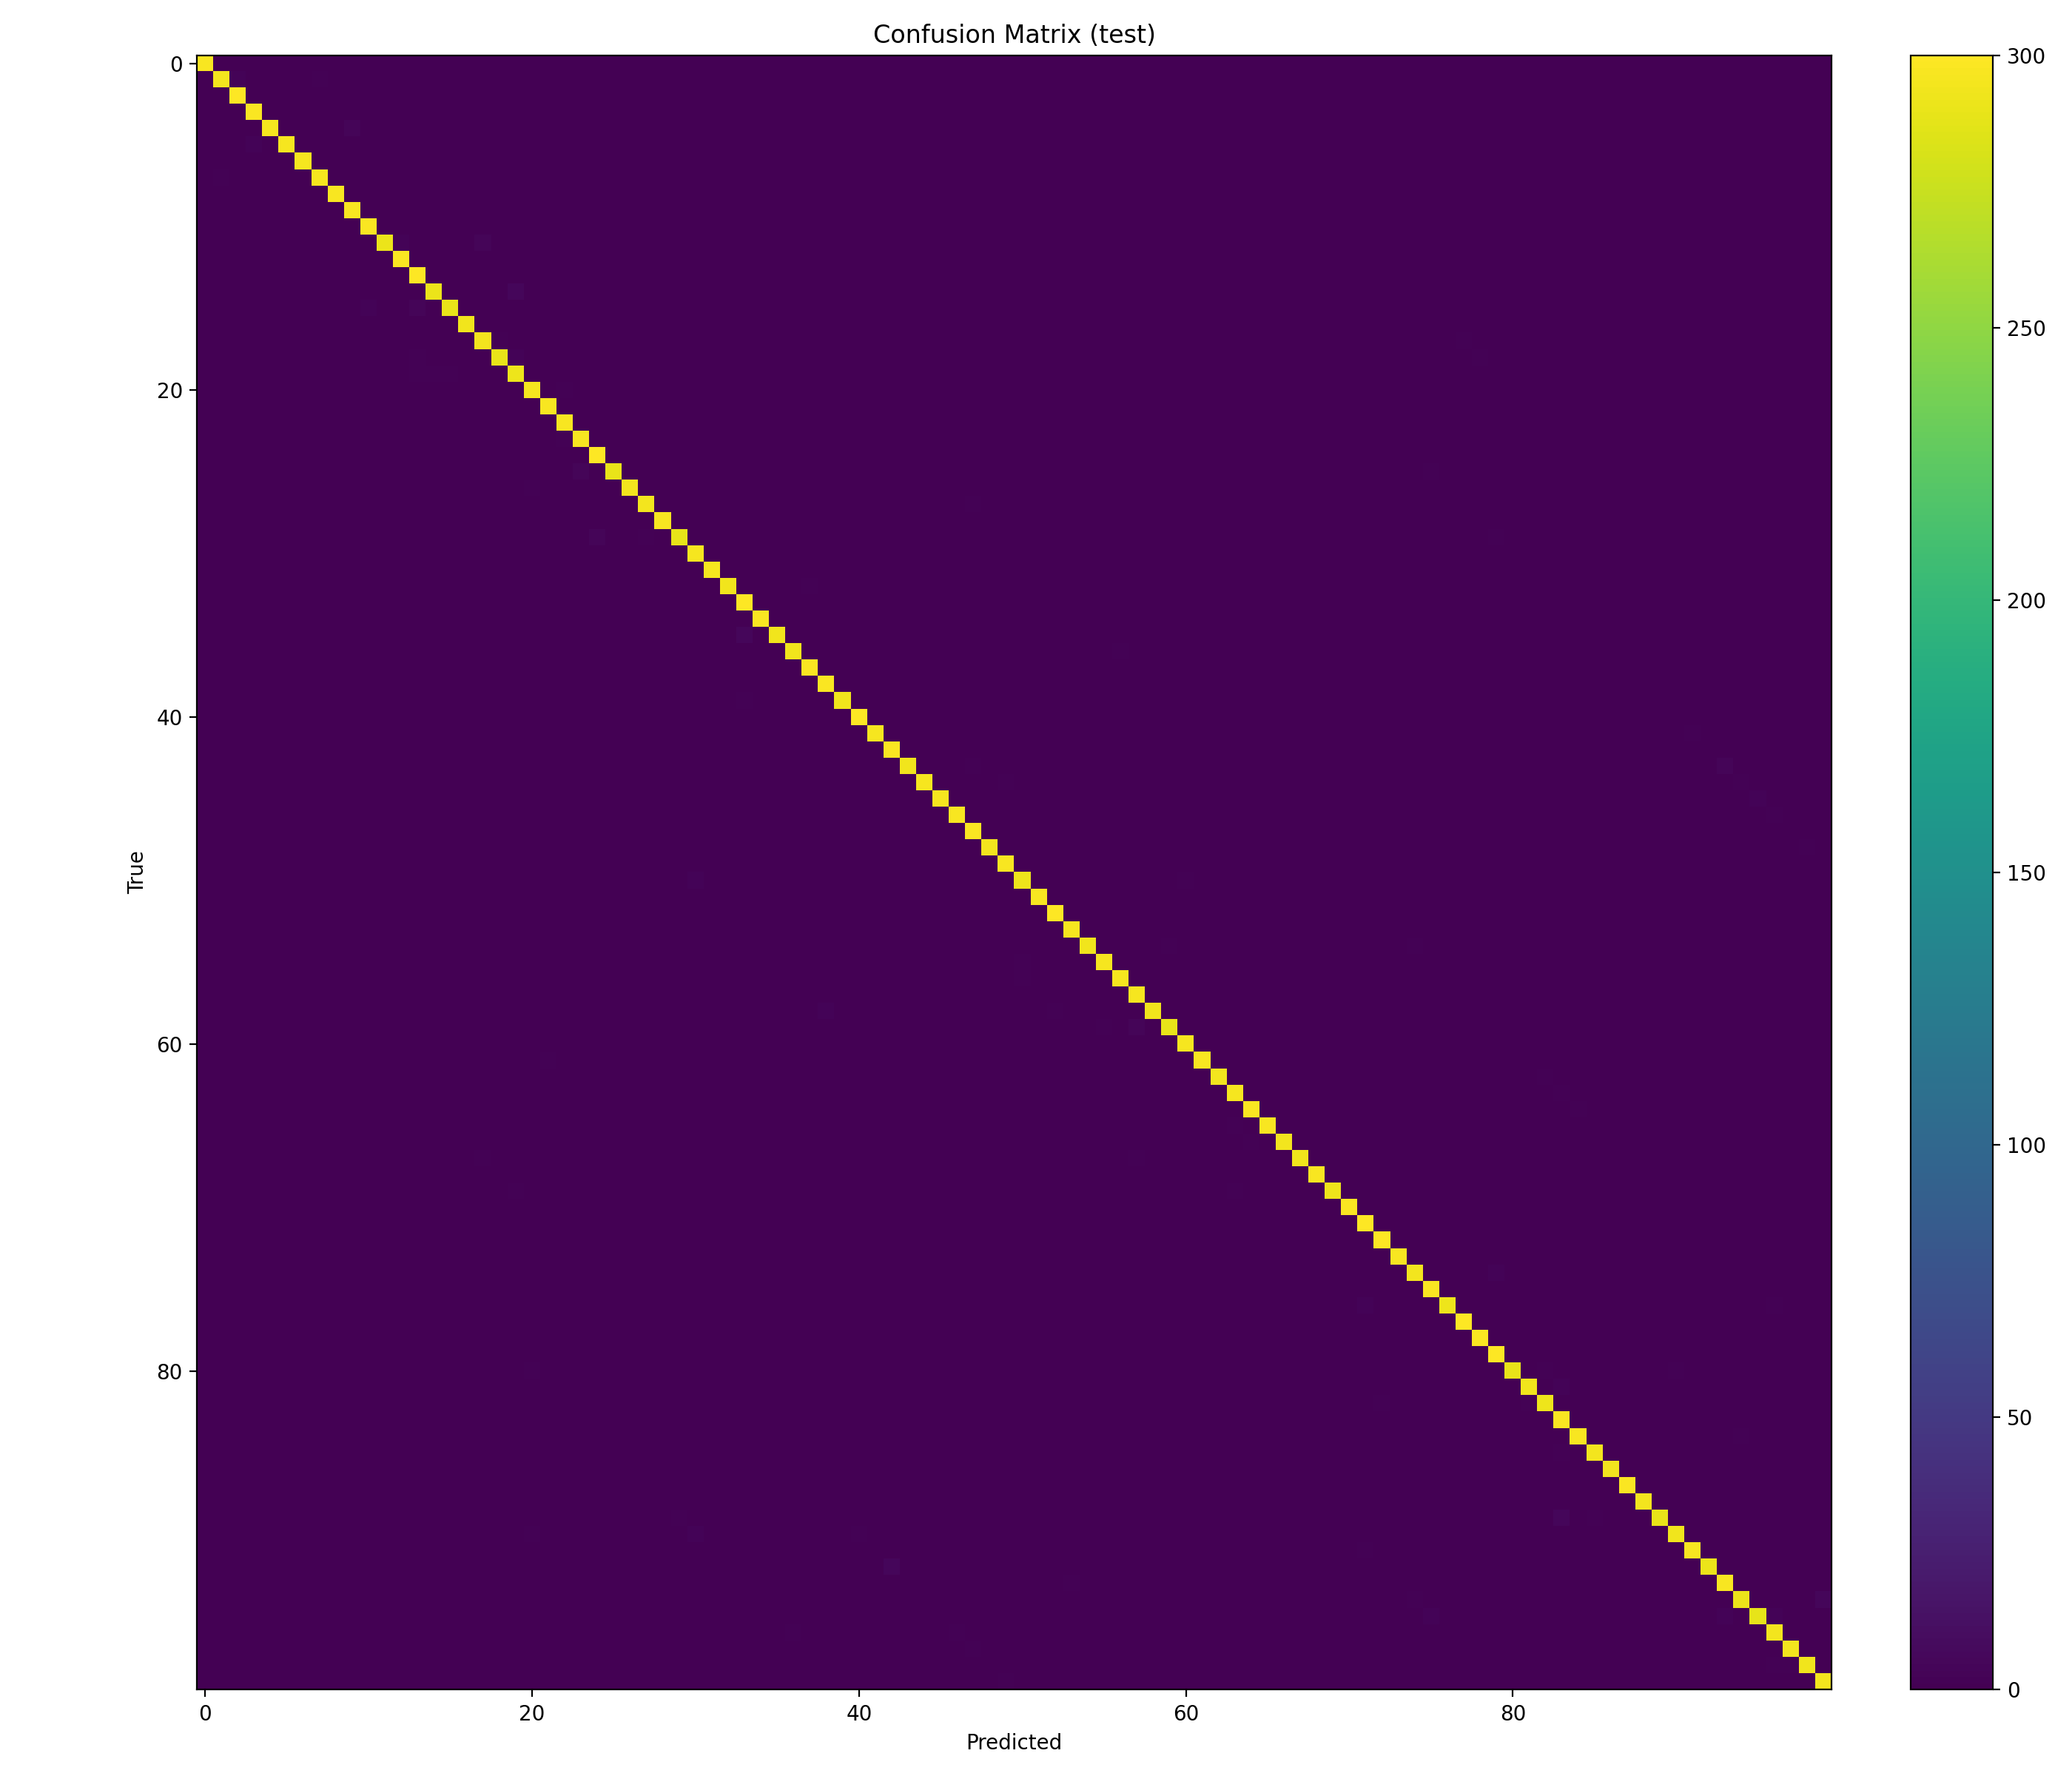

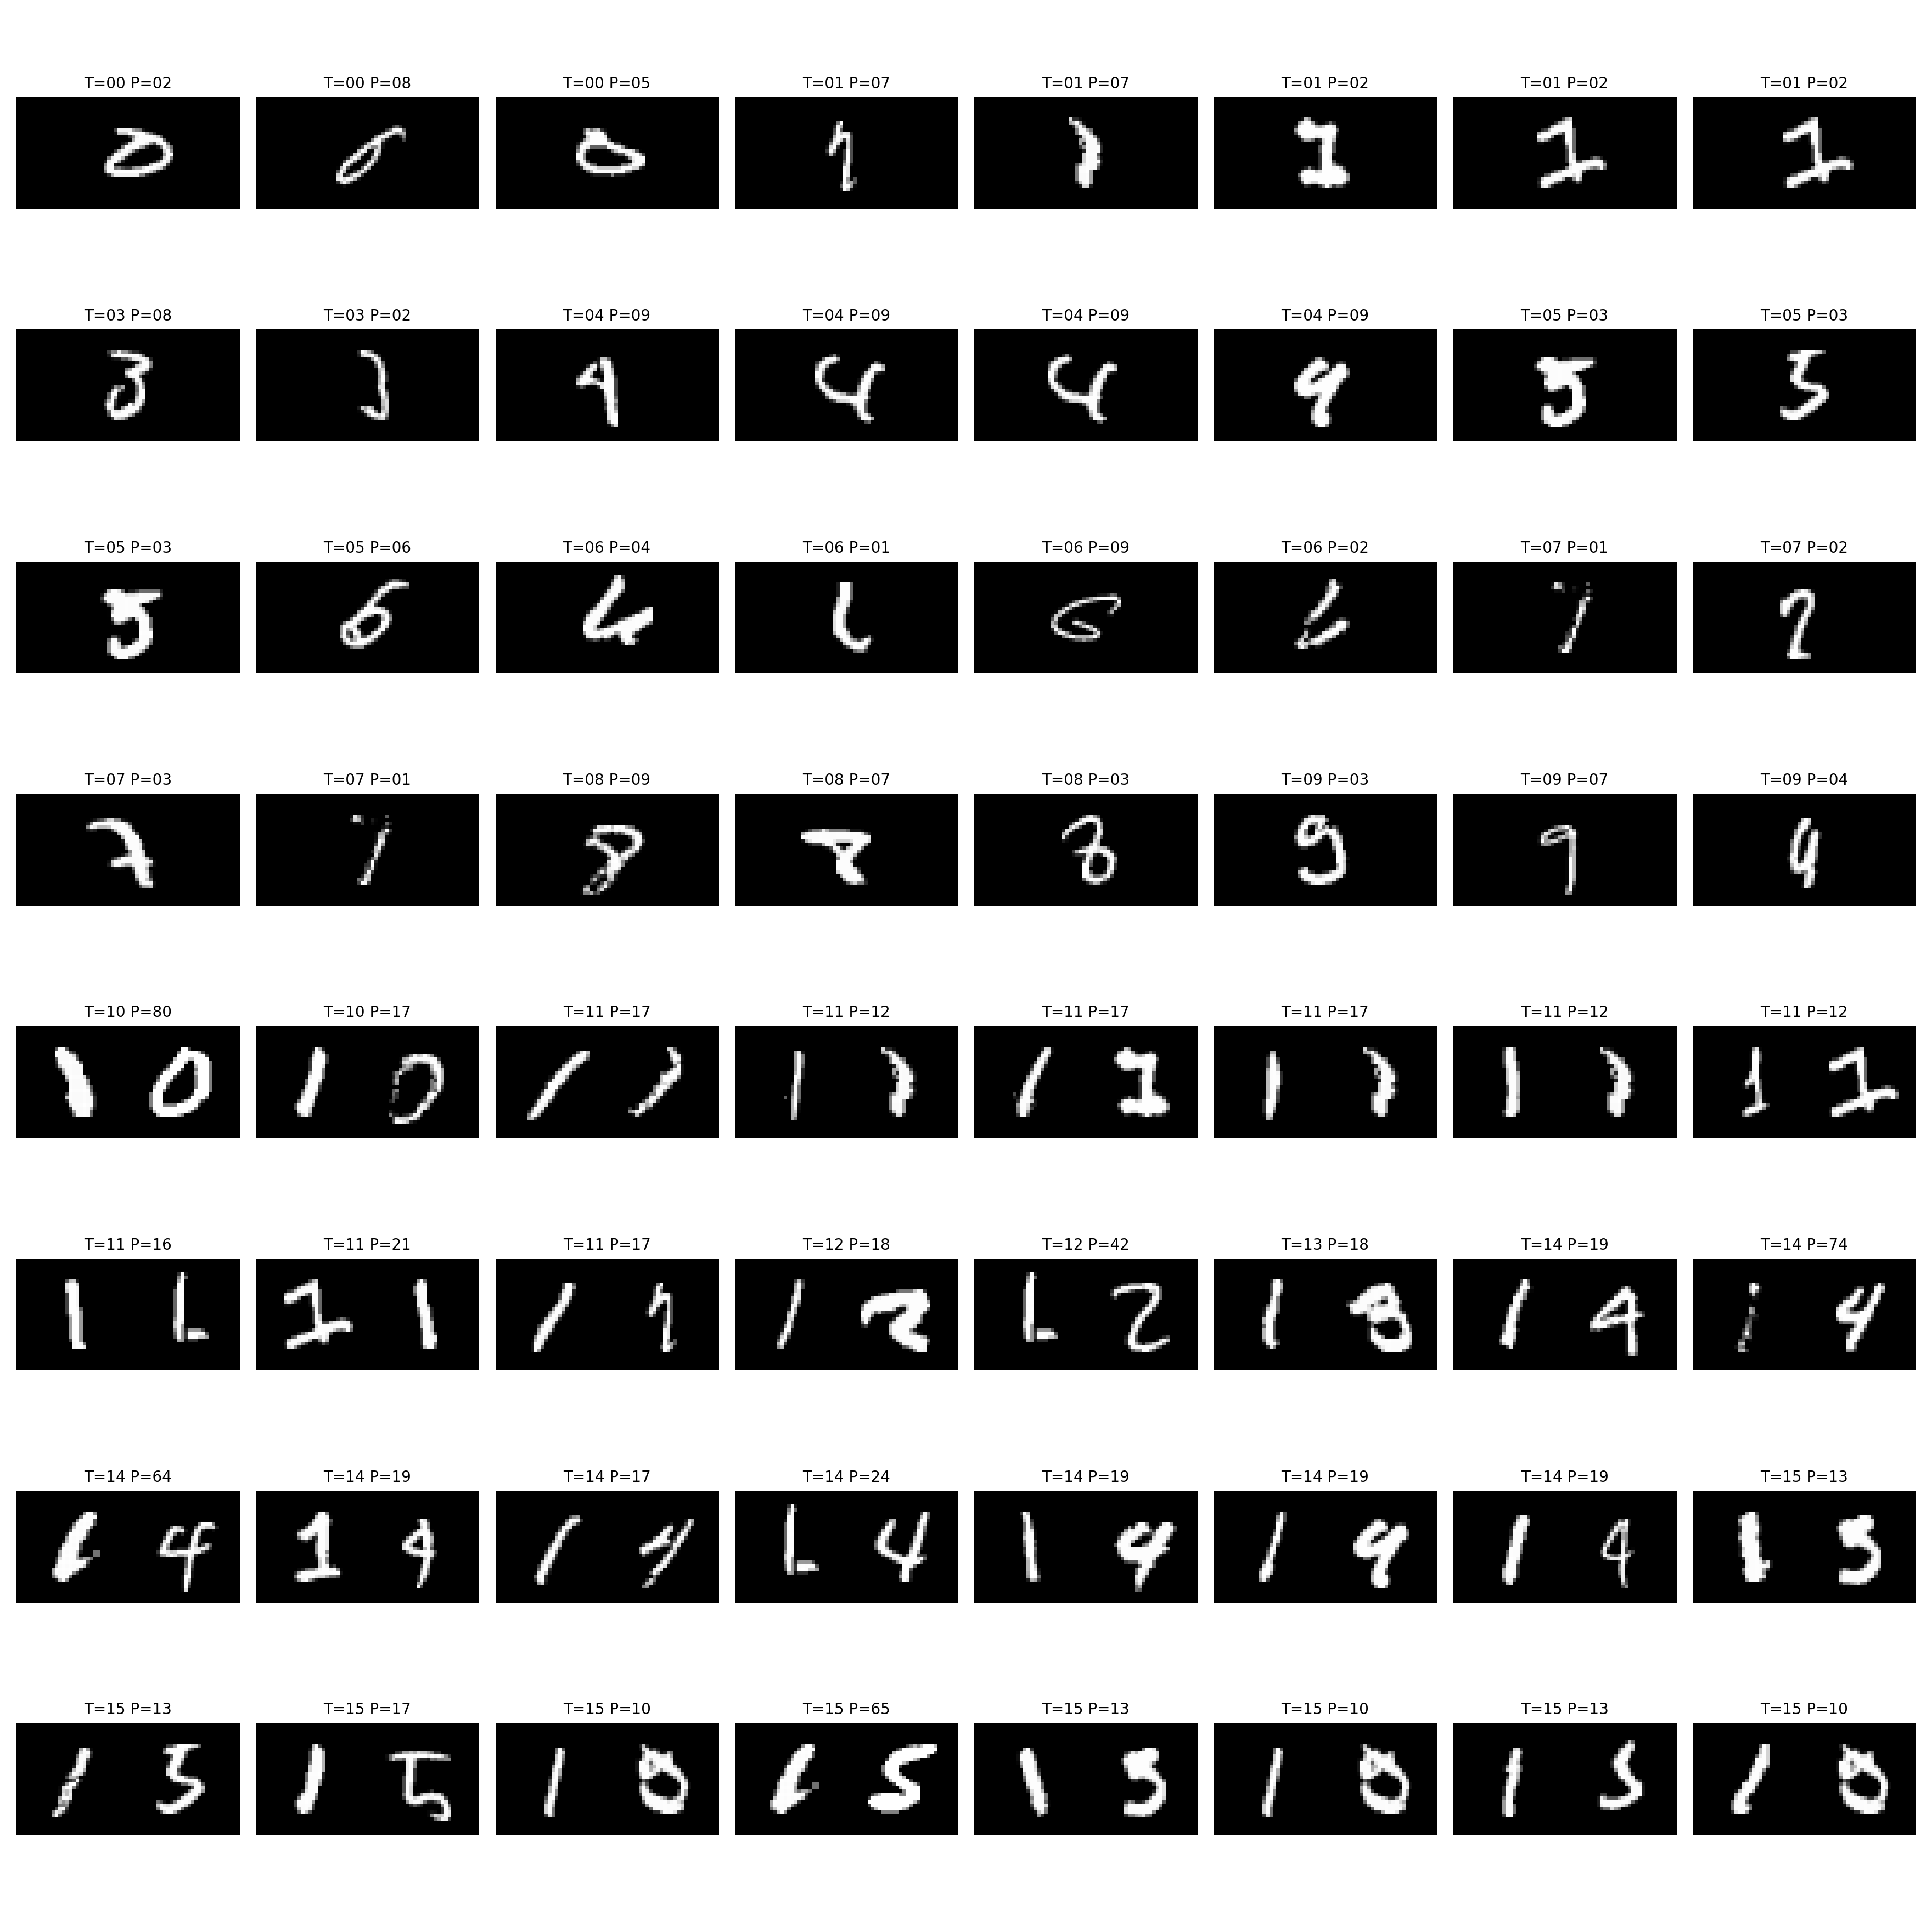

<Figure size 640x480 with 0 Axes>

In [41]:
%run /kaggle/working/eval_lenet99_ablation.py --training_conf /kaggle/working/configs/ablations/A0_base_adam.yaml --ckpt /kaggle/working/checkpoints/A0_base_adam/best.pt --split test --save_dir /kaggle/working/artifacts/ablation/A0_base_adam --max_wrong 64


## A1_sgd_momentum
> In this run Adam is replaced by SGD (Stochastic Gradient Descend) + momentum to study the effect of using a different optimizer.
SGD needs a higher learning rate and may converge more slowly but can sometimes yield better generalization.
We compare learning curves (train/val) and final test metrics against the Adam baseline.

In [18]:
%%writefile /kaggle/working/configs/ablations/A1_sgd_momentum.yaml
run:
  name: "A1_sgd_momentum"

train:
  epochs: 10
  batch_size: 256
  lr: 0.05          # SGD requires higher lr
  num_workers: 2
  print_every: 300
  use_amp: true
  seed: 42

paths:
  dataset_conf: "/kaggle/working/configs/dataset_conf.yaml"
  ckpt_dir: "/kaggle/working/checkpoints"
  runs_dir: "/kaggle/working/runs"

resume:
  path: ""

optimizer:
  name: "sgd"
  momentum: 0.9
  weight_decay: 0.0005

model:
  dropout: 0.1
  final_pool: "avg"

Writing /kaggle/working/configs/ablations/A1_sgd_momentum.yaml


In [22]:
!python /kaggle/working/train_lenet99_ablation.py --config /kaggle/working/configs/ablations/A1_sgd_momentum.yaml


2026-03-04 10:49:40.661368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772621380.685175    1147 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772621380.692434    1147 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772621380.711002    1147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772621380.711034    1147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772621380.711040    1147 computation_placer.cc:177] computation placer alr

{
  "split": "test",
  "ckpt": "/kaggle/working/checkpoints/A1_sgd_momentum/best.pt",
  "loss": 0.05770108209053675,
  "accuracy": 0.9823,
  "num_samples": 30000,
  "group_accuracy": {
    "acc_0_9": 0.9836666666666667,
    "n_0_9": 3000,
    "acc_10_99": 0.9821481481481481,
    "n_10_99": 27000
  },
  "num_wrong": 531
}
Saved metrics to: /kaggle/working/artifacts/ablation/A1_sgd_momentum/metrics_test.json

Top-10 confusions (True -> Pred : count)
57 -> 37 : 8
49 -> 44 : 7
15 -> 13 : 7
92 -> 42 : 7
39 -> 31 : 6
25 -> 23 : 6
76 -> 16 : 5
06 -> 05 : 4
23 -> 83 : 4
19 -> 14 : 4


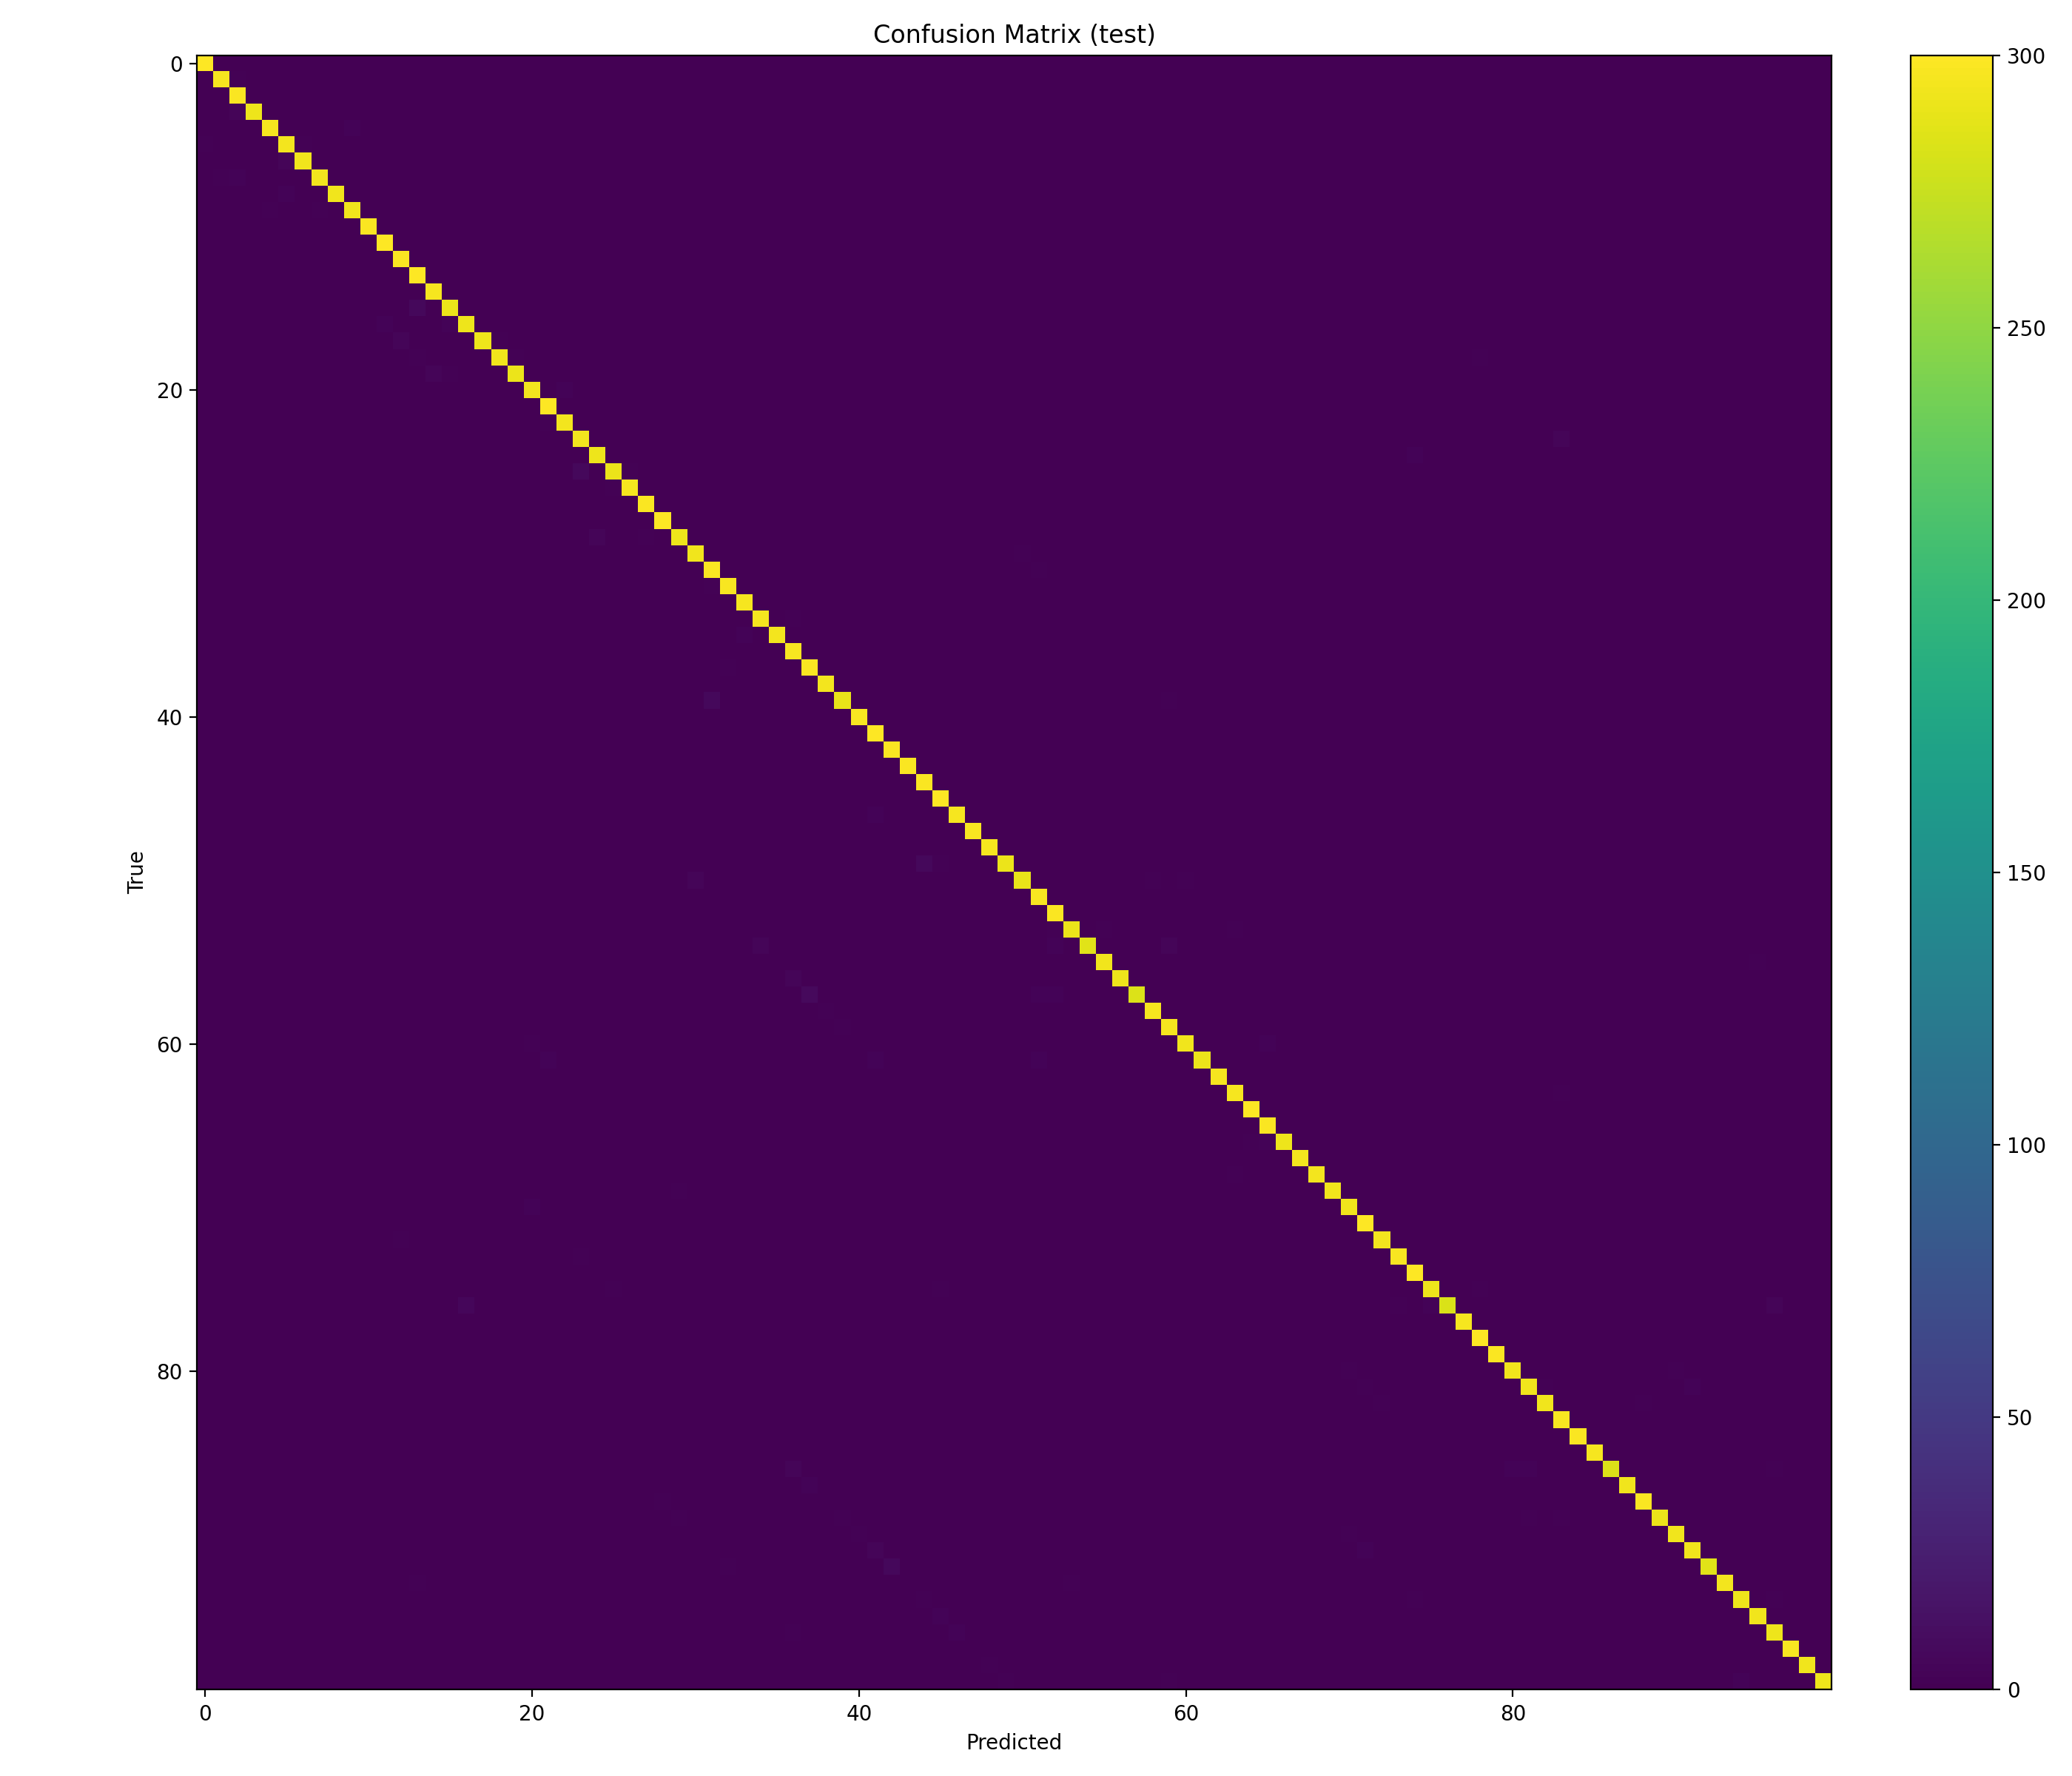

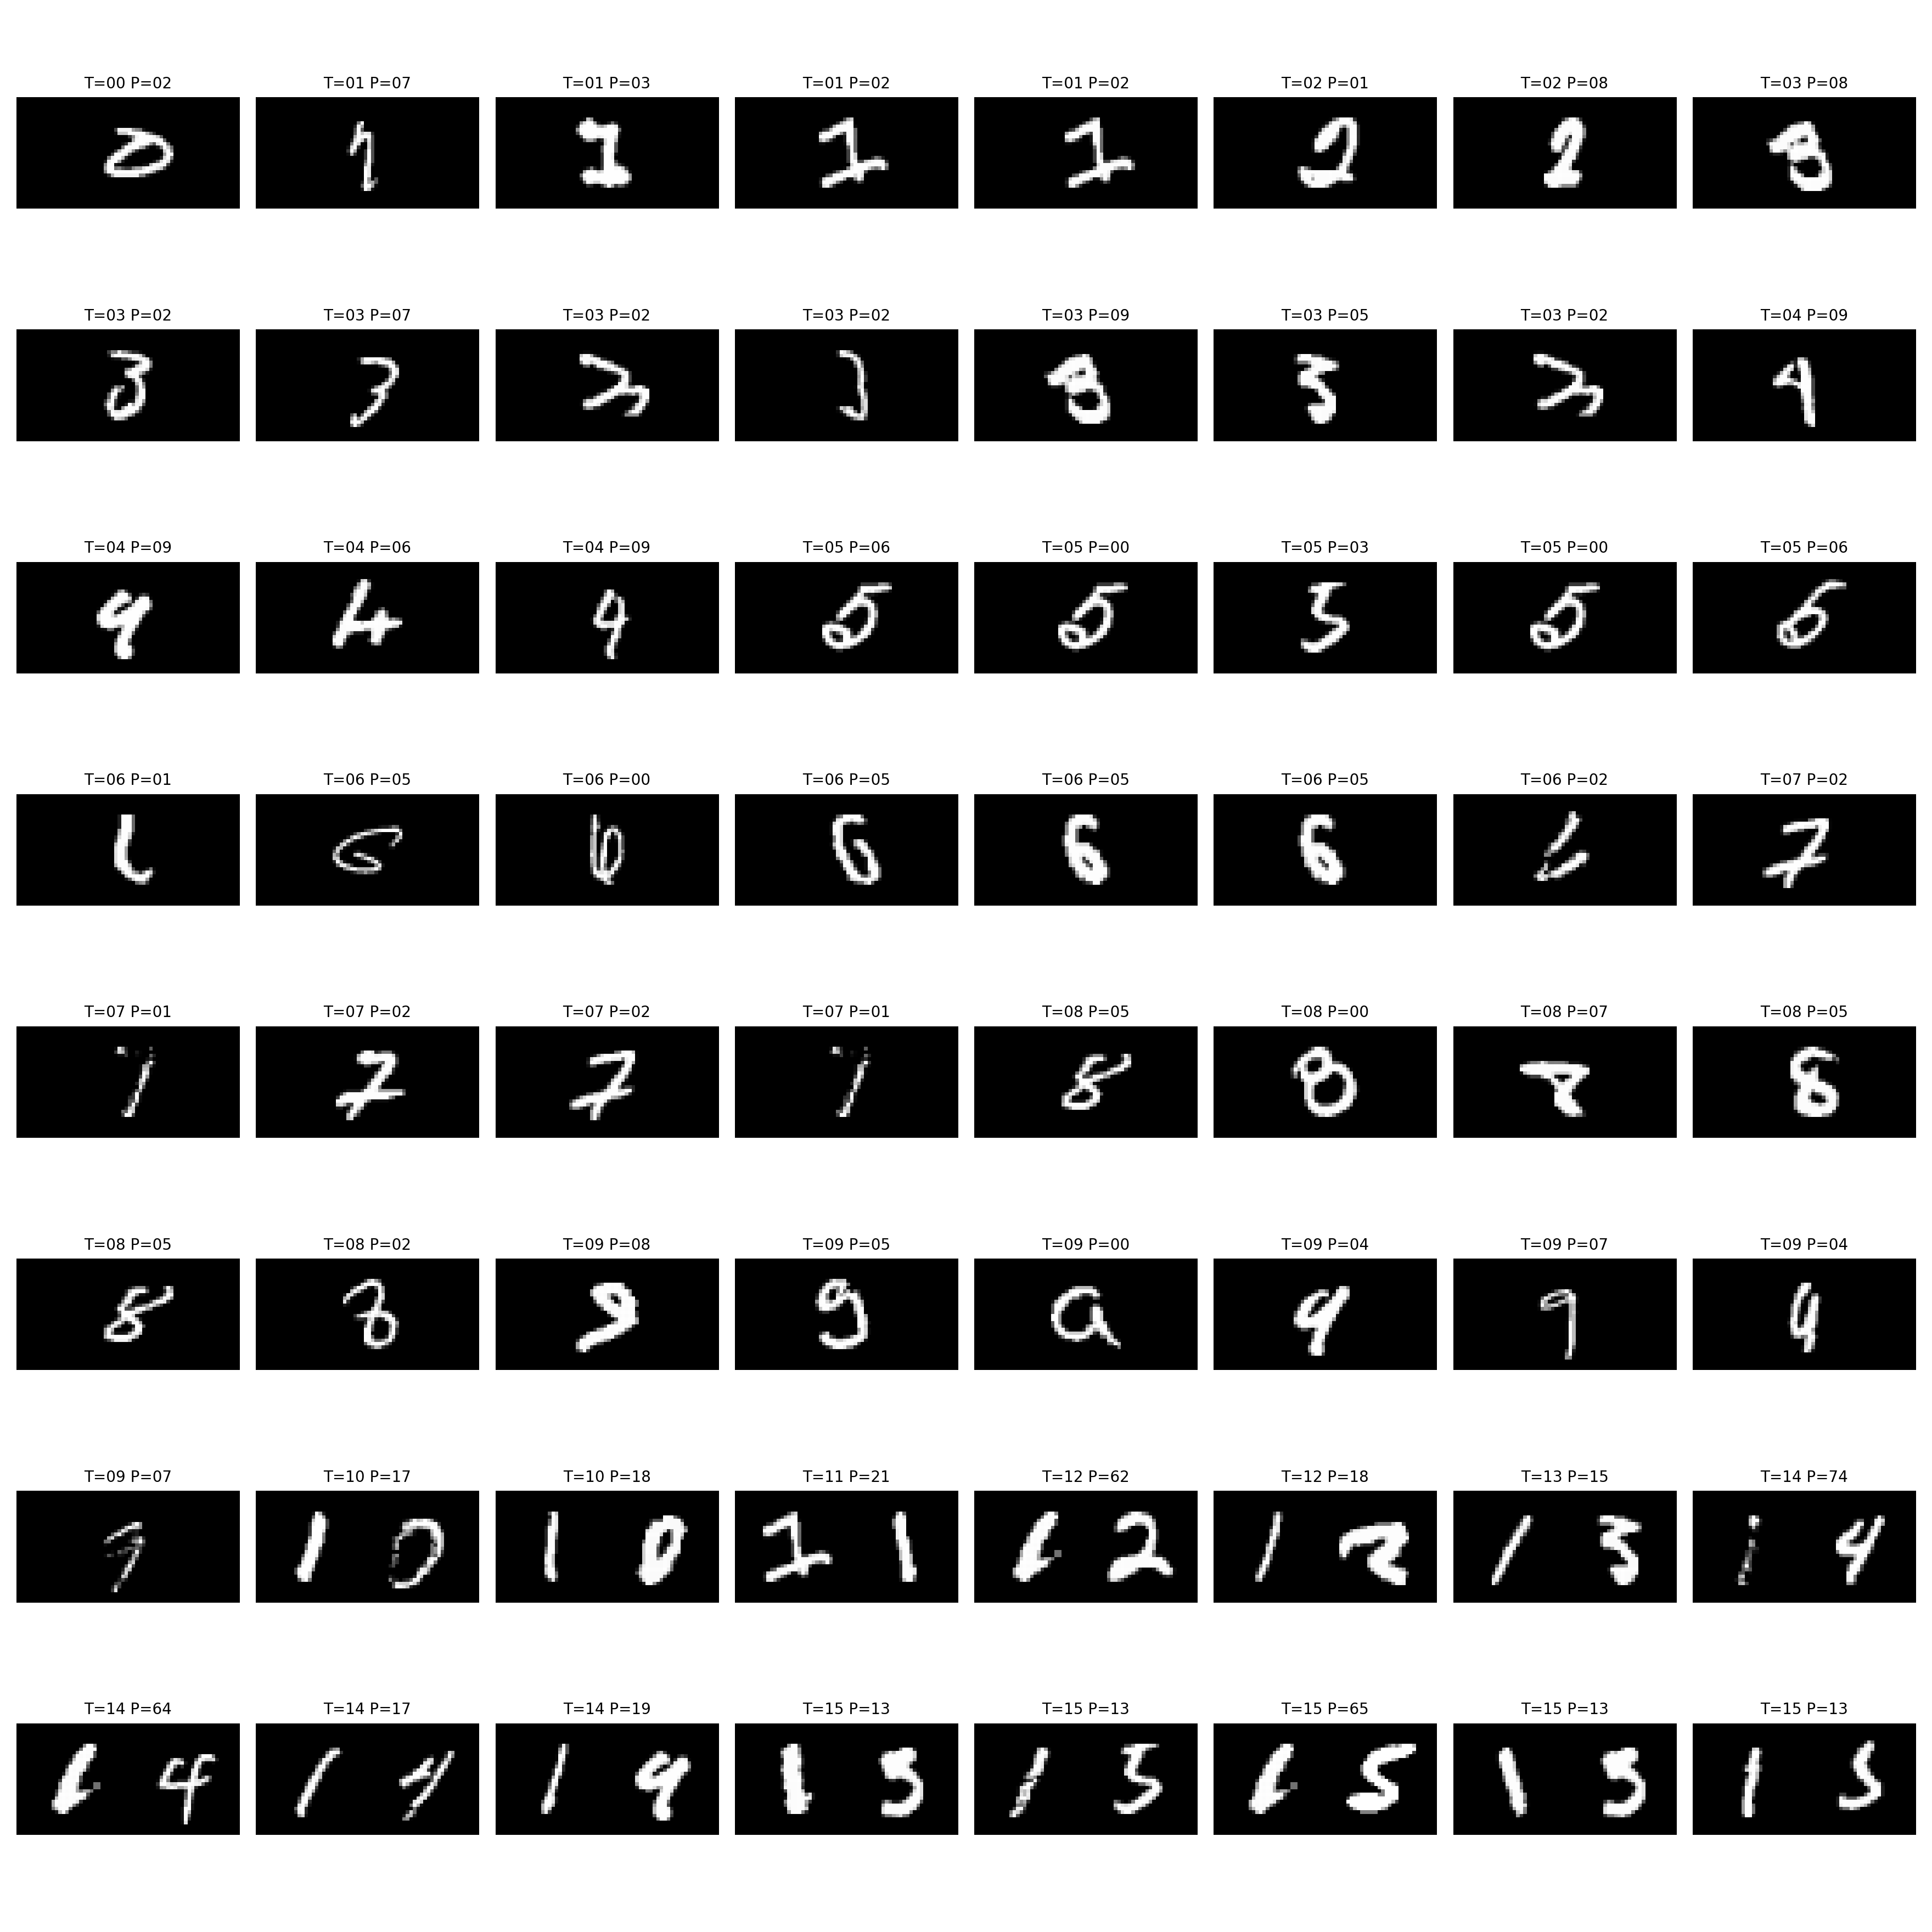

<Figure size 640x480 with 0 Axes>

In [42]:
%run /kaggle/working/eval_lenet99_ablation.py --training_conf /kaggle/working/configs/ablations/A1_sgd_momentum.yaml --ckpt /kaggle/working/checkpoints/A1_sgd_momentum/best.pt --split test --save_dir /kaggle/working/artifacts/ablation/A1_sgd_momentum --max_wrong 64


## A2_dropout0
> In this run dropout is set to 0.0 to measure how much regularization is needed for MNIST99.
Removing dropout typically increases capacity and can improve training accuracy, but may hurt validation/test if overfitting appears.
We inspect the train–val gap and whether test errors concentrate on specific confusion patterns.

In [19]:
%%writefile /kaggle/working/configs/ablations/A2_dropout0.yaml
run:
  name: "A2_dropout0"

train:
  epochs: 10
  batch_size: 256
  lr: 0.001
  num_workers: 2
  print_every: 300
  use_amp: true
  seed: 42

paths:
  dataset_conf: "/kaggle/working/configs/dataset_conf.yaml"
  ckpt_dir: "/kaggle/working/checkpoints"
  runs_dir: "/kaggle/working/runs"

resume:
  path: ""

optimizer:
  name: "adam"
  weight_decay: 0.0

model:
  dropout: 0.0
  final_pool: "avg"

Writing /kaggle/working/configs/ablations/A2_dropout0.yaml


In [23]:
!python /kaggle/working/train_lenet99_ablation.py --config /kaggle/working/configs/ablations/A2_dropout0.yaml


2026-03-04 10:51:07.771652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772621467.794233    1378 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772621467.800979    1378 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772621467.818562    1378 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772621467.818589    1378 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772621467.818594    1378 computation_placer.cc:177] computation placer alr

{
  "split": "test",
  "ckpt": "/kaggle/working/checkpoints/A2_dropout0/best.pt",
  "loss": 0.07280979237357775,
  "accuracy": 0.9795,
  "num_samples": 30000,
  "group_accuracy": {
    "acc_0_9": 0.9843333333333333,
    "n_0_9": 3000,
    "acc_10_99": 0.9789629629629629,
    "n_10_99": 27000
  },
  "num_wrong": 615
}
Saved metrics to: /kaggle/working/artifacts/ablation/A2_dropout0/metrics_test.json

Top-10 confusions (True -> Pred : count)
04 -> 09 : 8
43 -> 93 : 8
15 -> 13 : 7
36 -> 56 : 6
65 -> 55 : 5
96 -> 56 : 5
49 -> 48 : 5
46 -> 96 : 5
59 -> 55 : 5
62 -> 68 : 5


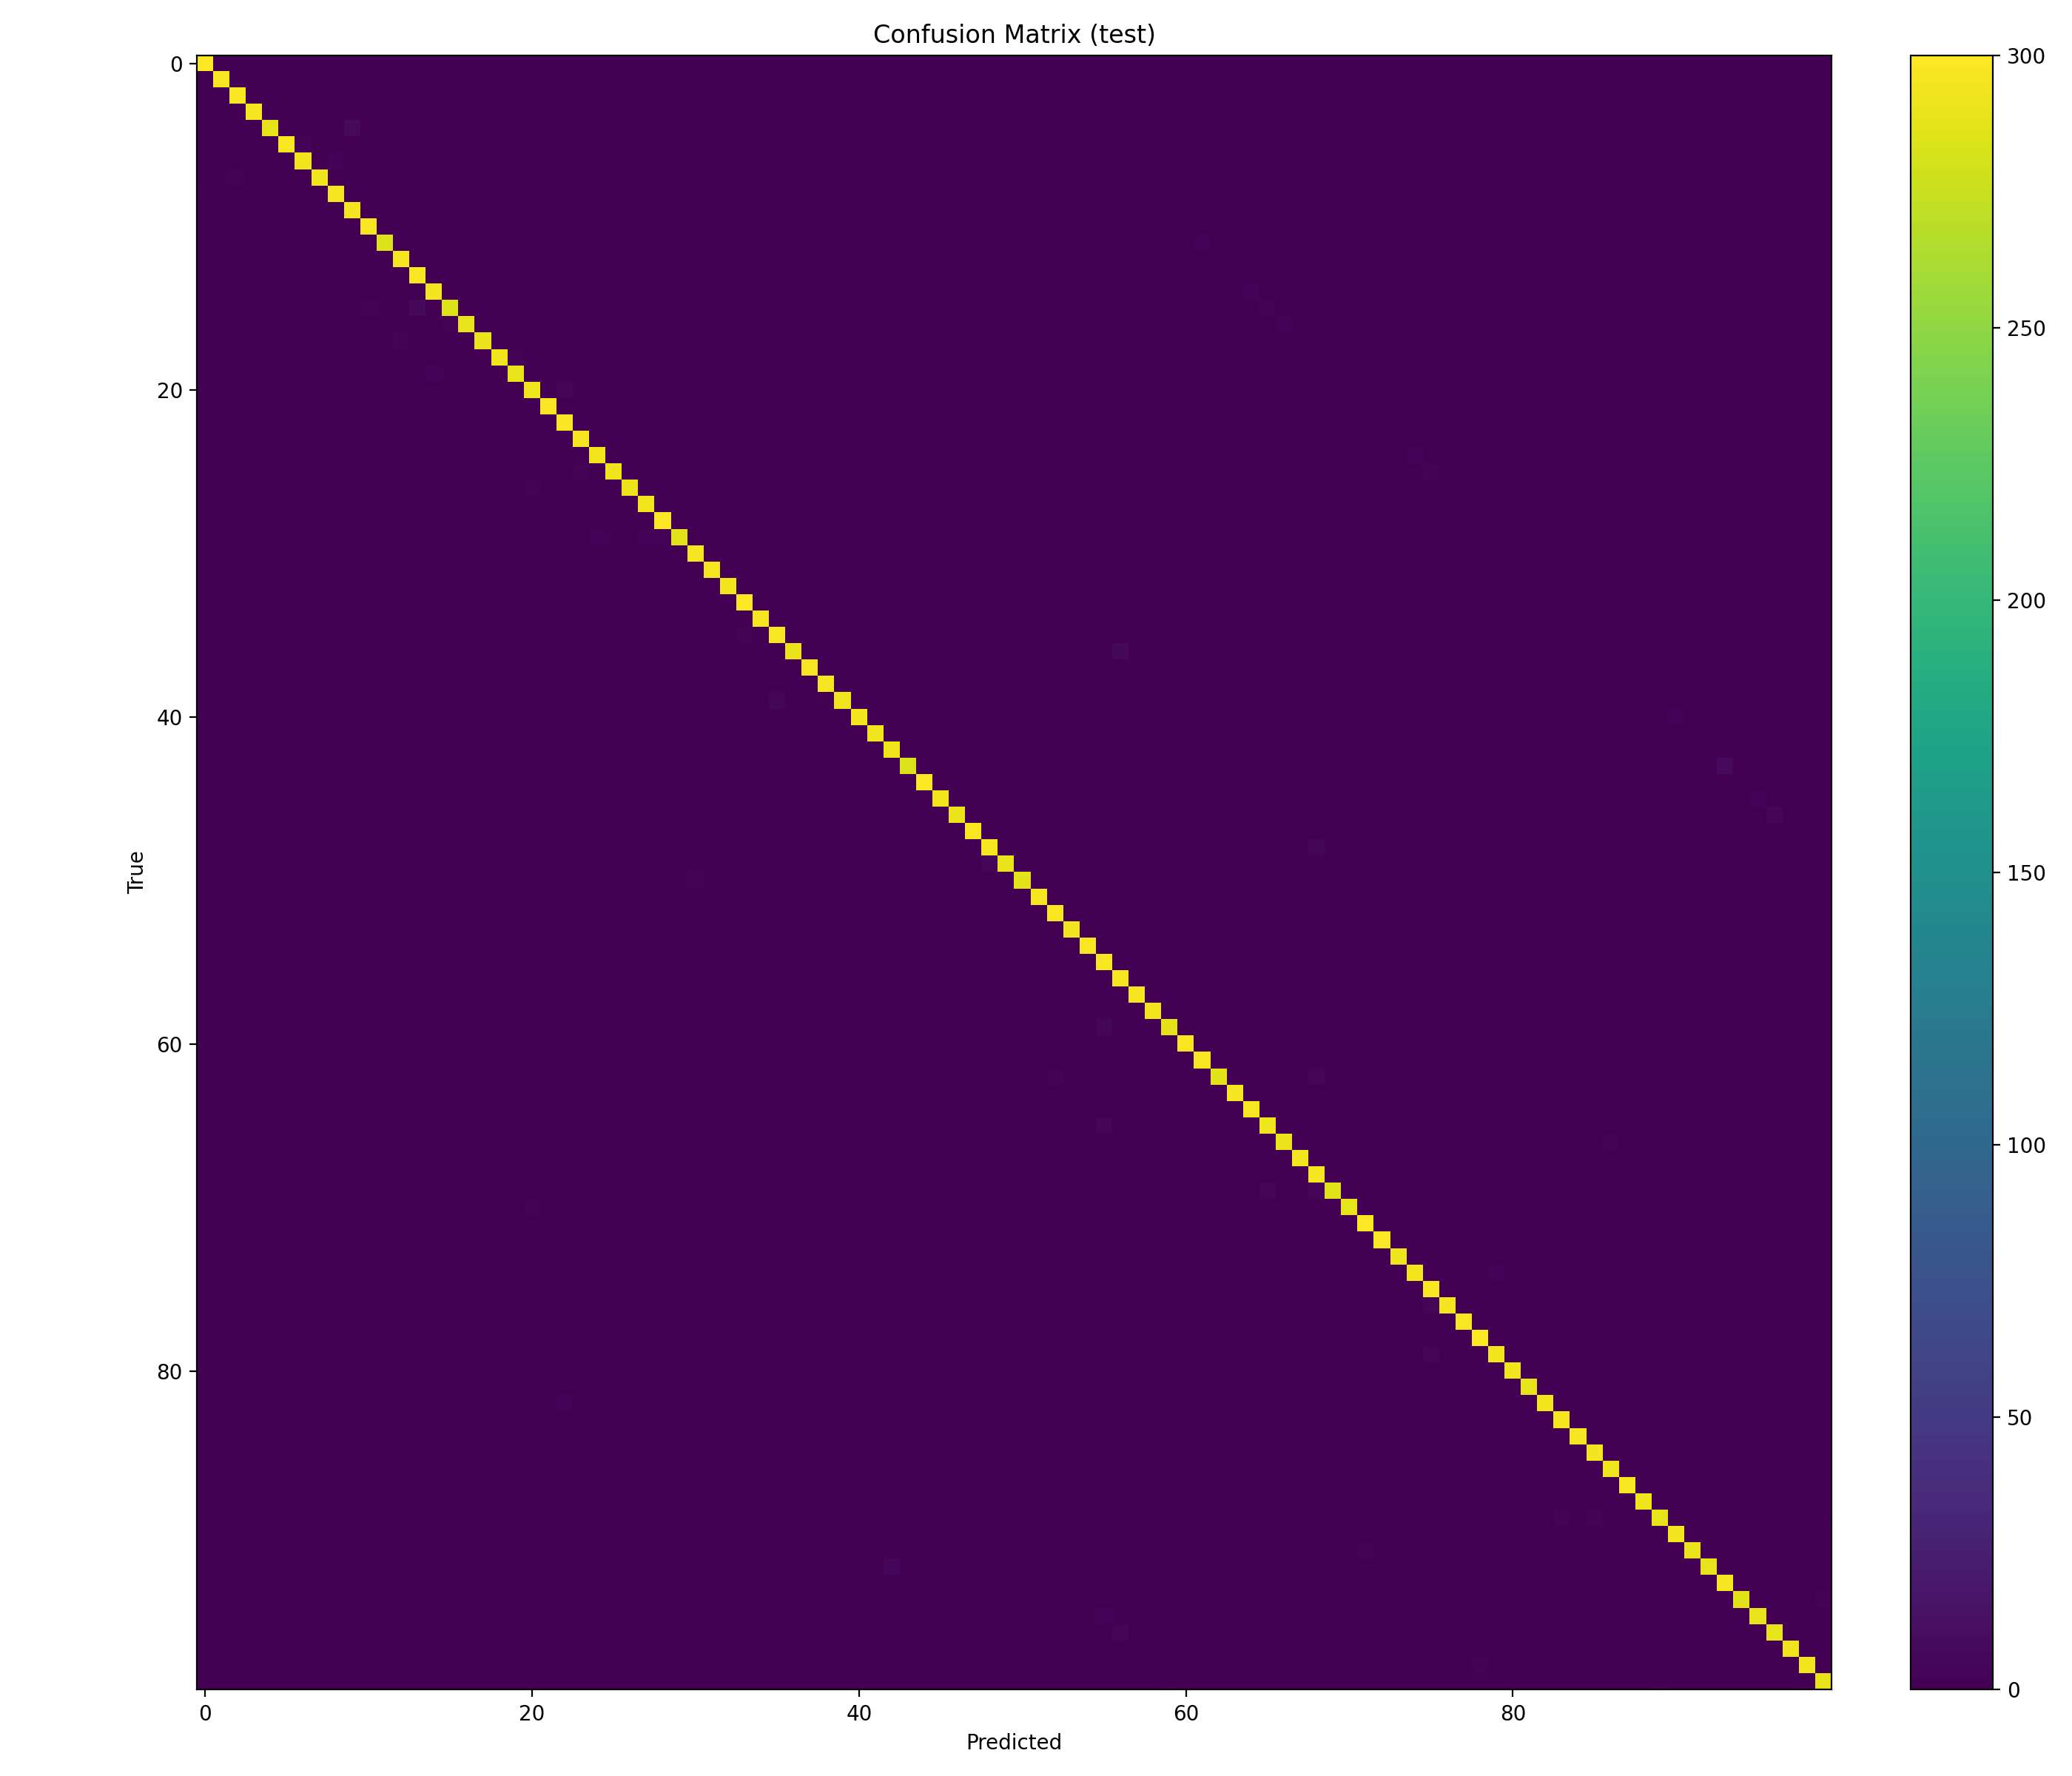

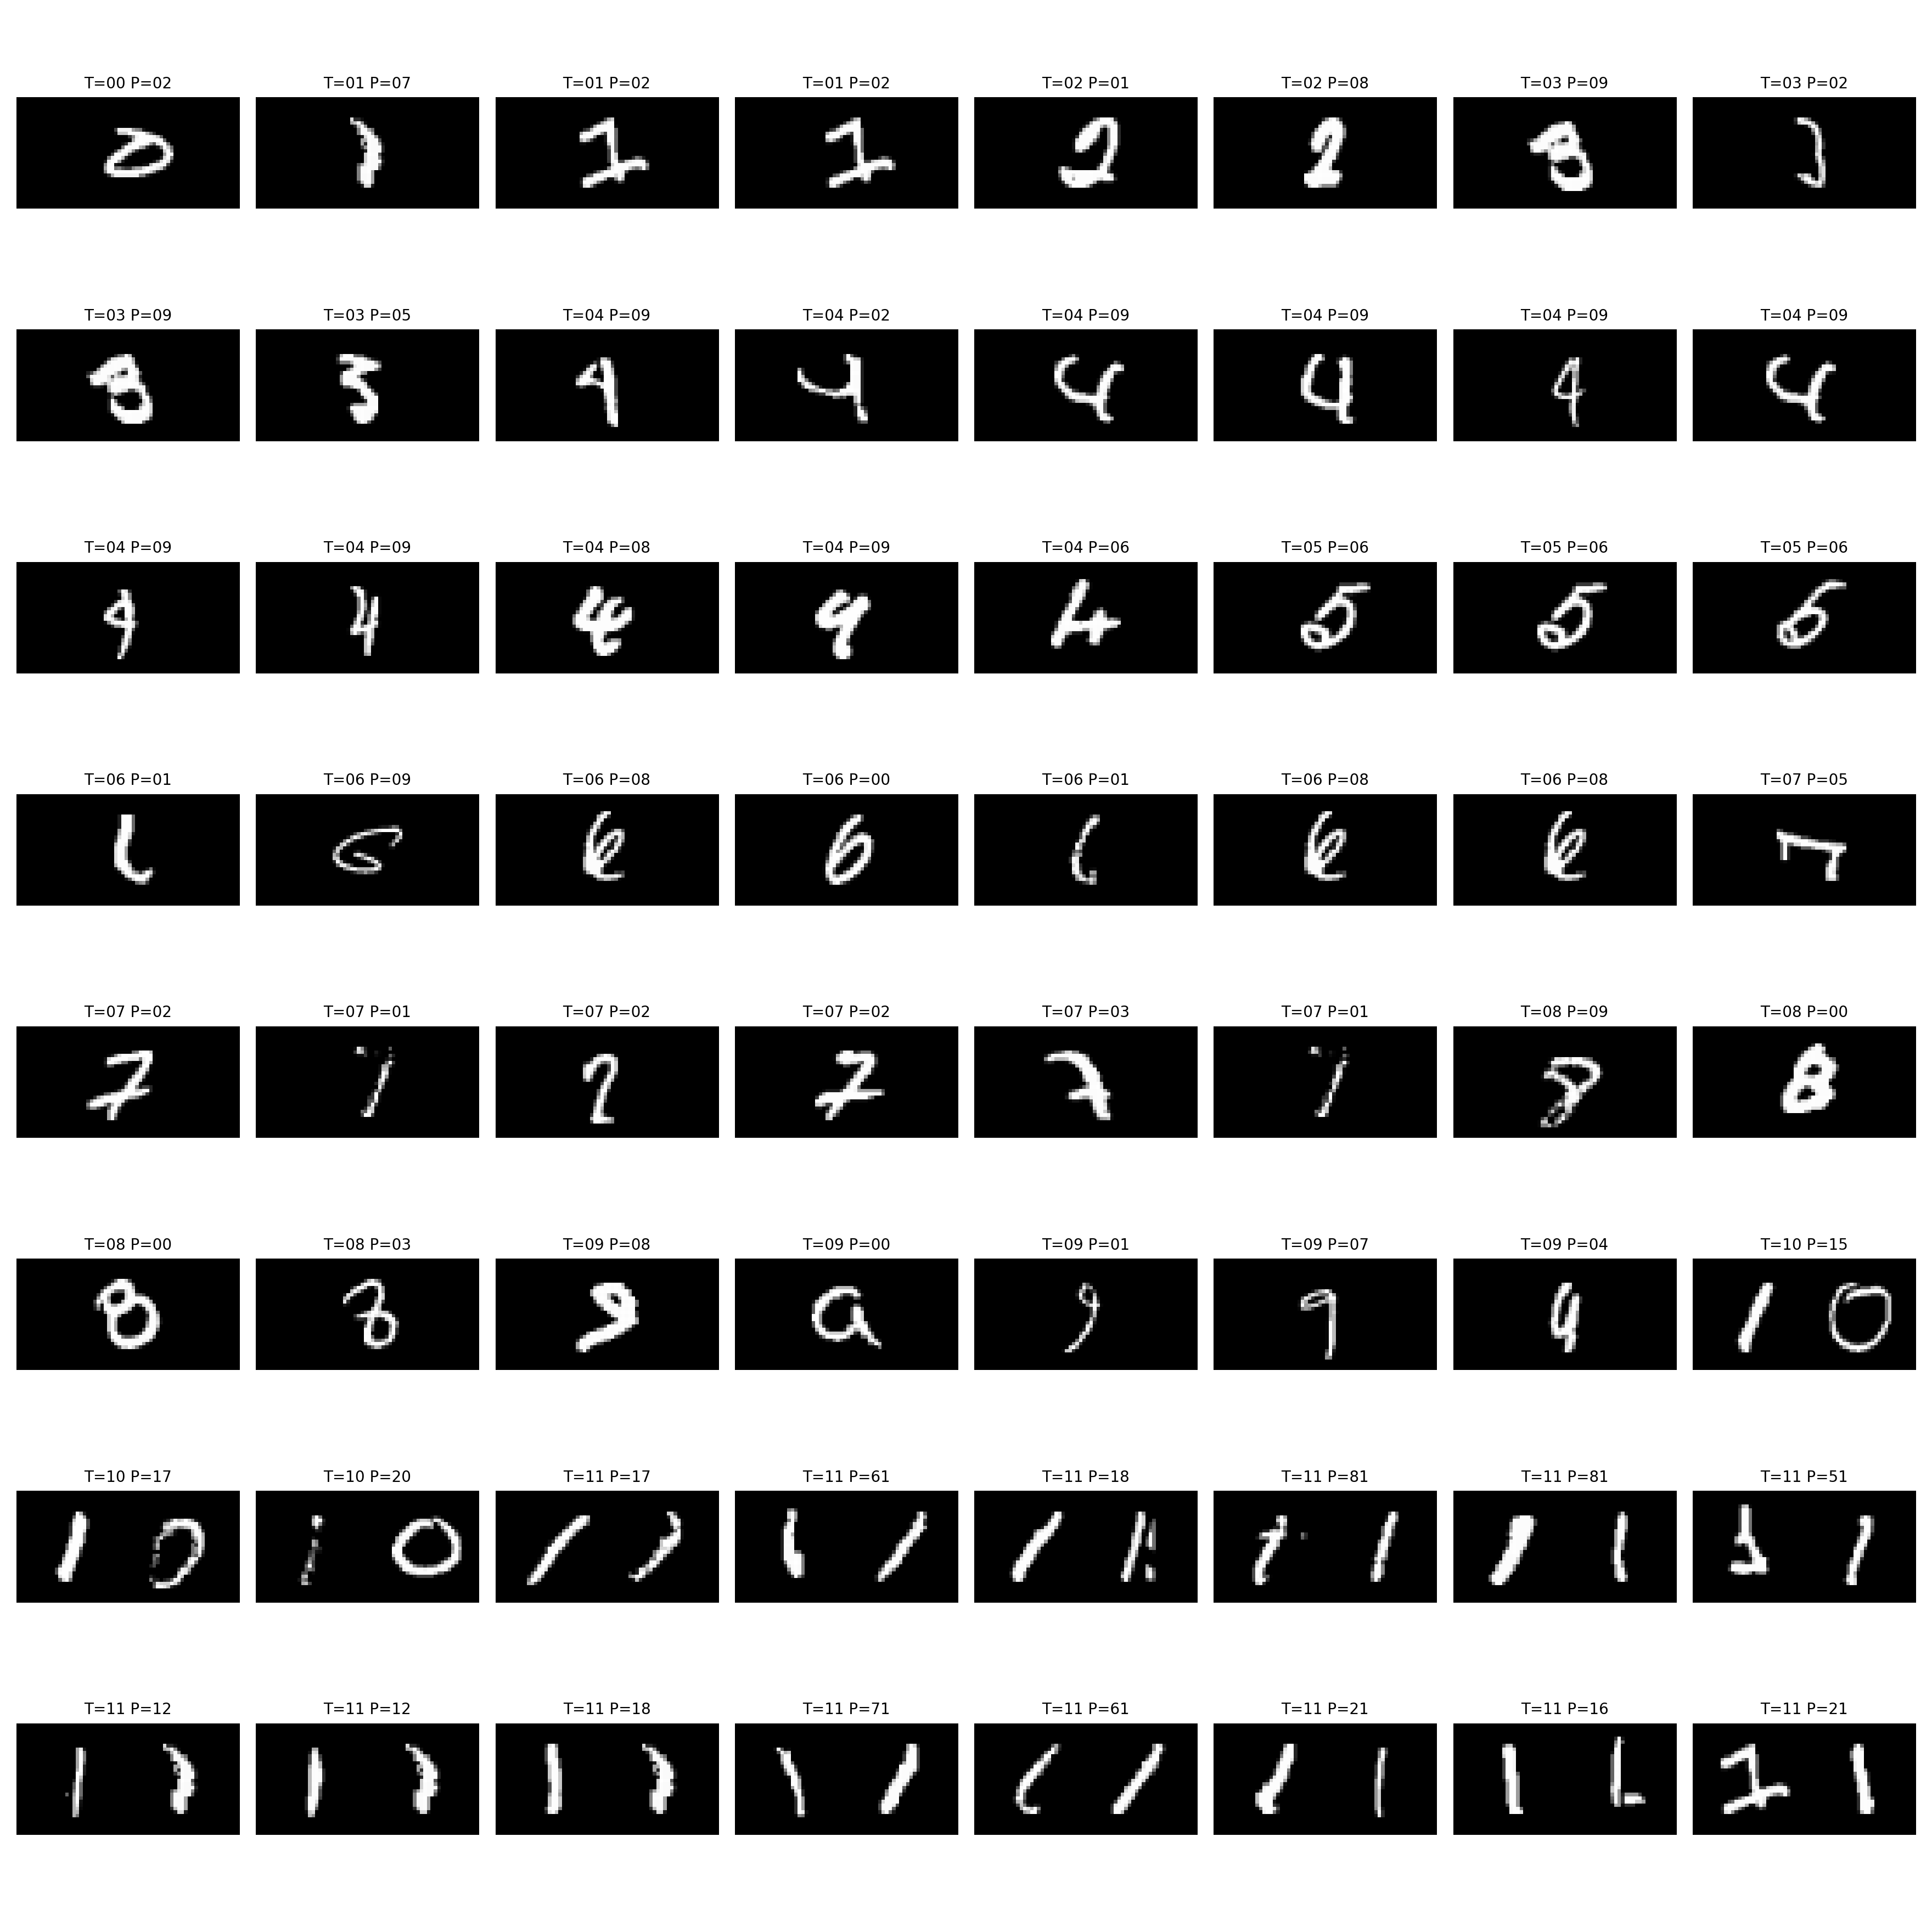

<Figure size 640x480 with 0 Axes>

In [43]:
%run /kaggle/working/eval_lenet99_ablation.py --training_conf /kaggle/working/configs/ablations/A2_dropout0.yaml --ckpt /kaggle/working/checkpoints/A2_dropout0/best.pt --split test --save_dir /kaggle/working/artifacts/ablation/A2_dropout0 --max_wrong 64


## A3_poolmax
> In this run AveragePool(1×2) is changed to MaxPool(1×2).
Max pooling is more selective and may preserve strong strokes, potentially helping discriminative local features.
Average pooling is smoother and may be more robust to noise/variations, so the trade-off is not obvious a priori.
We compare accuracy and error modes (confusion matrix and wrong-grid) to see if pooling affects specific digit-pair confusions.

In [20]:
%%writefile /kaggle/working/configs/ablations/A3_poolmax.yaml
run:
  name: "A3_poolmax"

train:
  epochs: 10
  batch_size: 256
  lr: 0.001
  num_workers: 2
  print_every: 300
  use_amp: true
  seed: 42

paths:
  dataset_conf: "/kaggle/working/configs/dataset_conf.yaml"
  ckpt_dir: "/kaggle/working/checkpoints"
  runs_dir: "/kaggle/working/runs"

resume:
  path: ""

optimizer:
  name: "adam"
  weight_decay: 0.0

model:
  dropout: 0.1
  final_pool: "max"

Writing /kaggle/working/configs/ablations/A3_poolmax.yaml


In [24]:
!python /kaggle/working/train_lenet99_ablation.py --config /kaggle/working/configs/ablations/A3_poolmax.yaml

2026-03-04 10:52:35.002040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772621555.026647    1601 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772621555.033990    1601 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772621555.052873    1601 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772621555.052902    1601 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772621555.052906    1601 computation_placer.cc:177] computation placer alr

{
  "split": "test",
  "ckpt": "/kaggle/working/checkpoints/A3_poolmax/best.pt",
  "loss": 0.07024846522460382,
  "accuracy": 0.9813,
  "num_samples": 30000,
  "group_accuracy": {
    "acc_0_9": 0.9846666666666667,
    "n_0_9": 3000,
    "acc_10_99": 0.980925925925926,
    "n_10_99": 27000
  },
  "num_wrong": 561
}
Saved metrics to: /kaggle/working/artifacts/ablation/A3_poolmax/metrics_test.json

Top-10 confusions (True -> Pred : count)
15 -> 13 : 8
62 -> 52 : 5
42 -> 48 : 5
61 -> 51 : 5
35 -> 33 : 5
27 -> 87 : 4
91 -> 71 : 4
92 -> 42 : 4
19 -> 13 : 4
77 -> 72 : 4


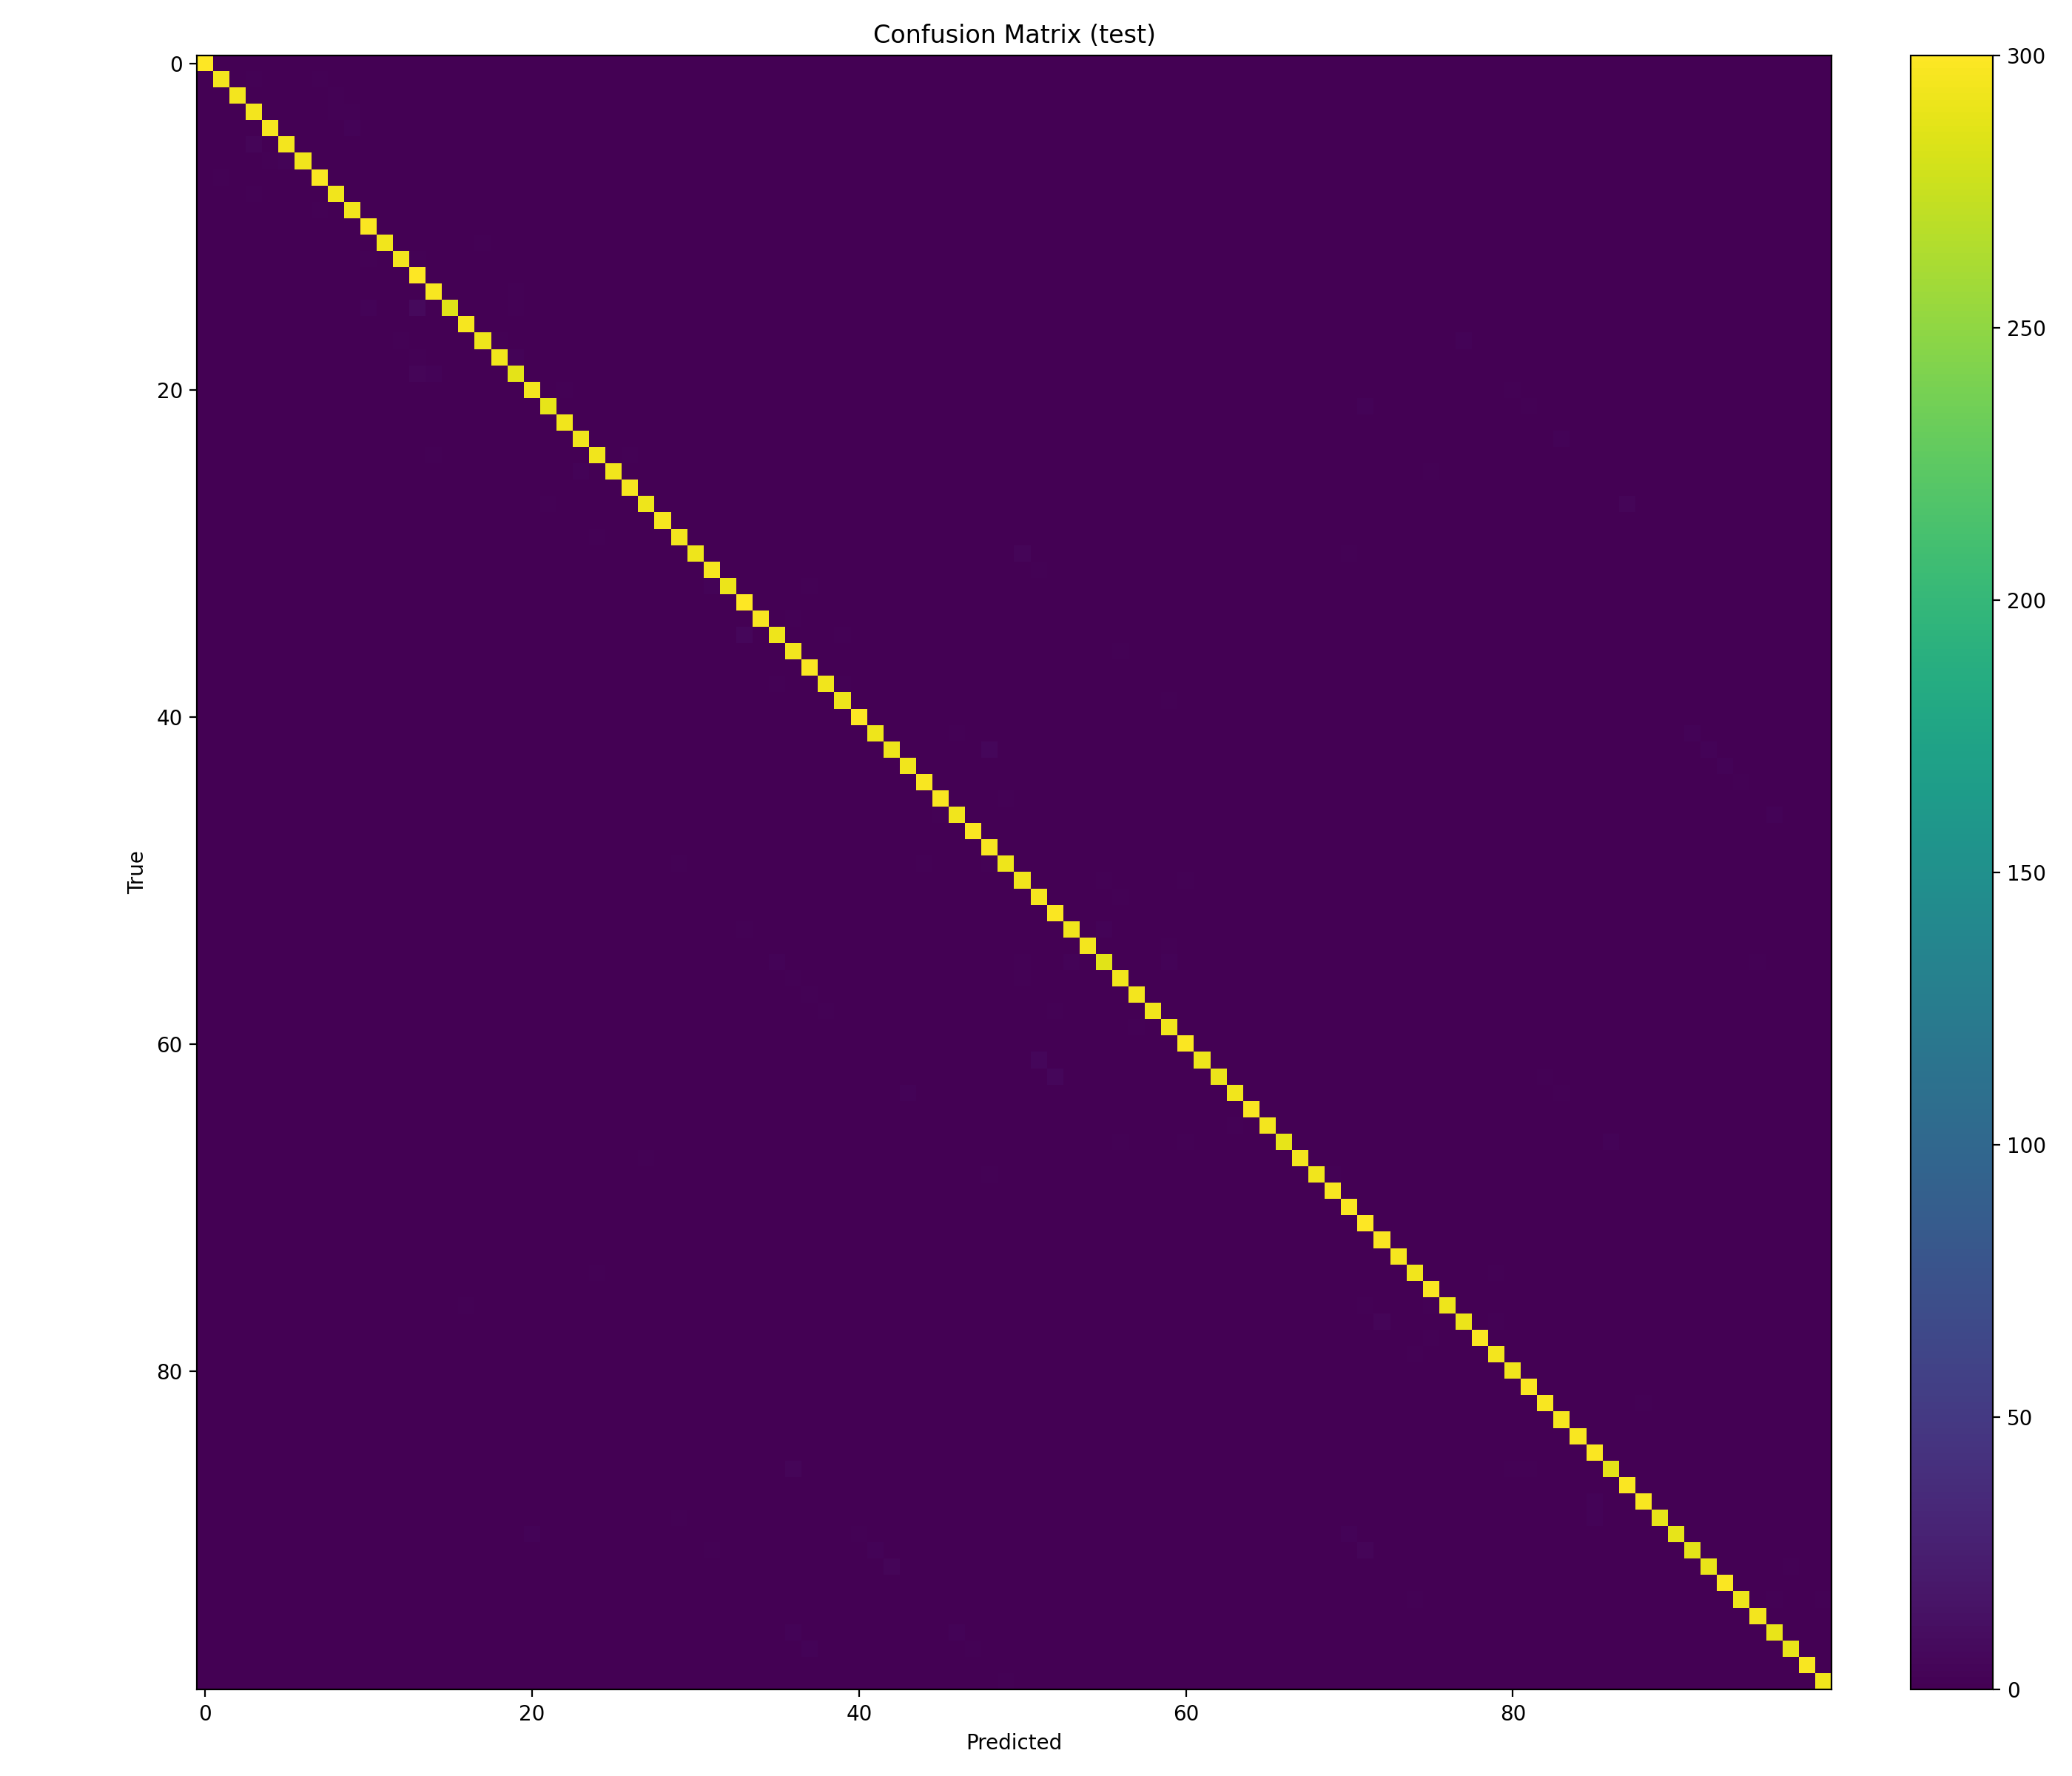

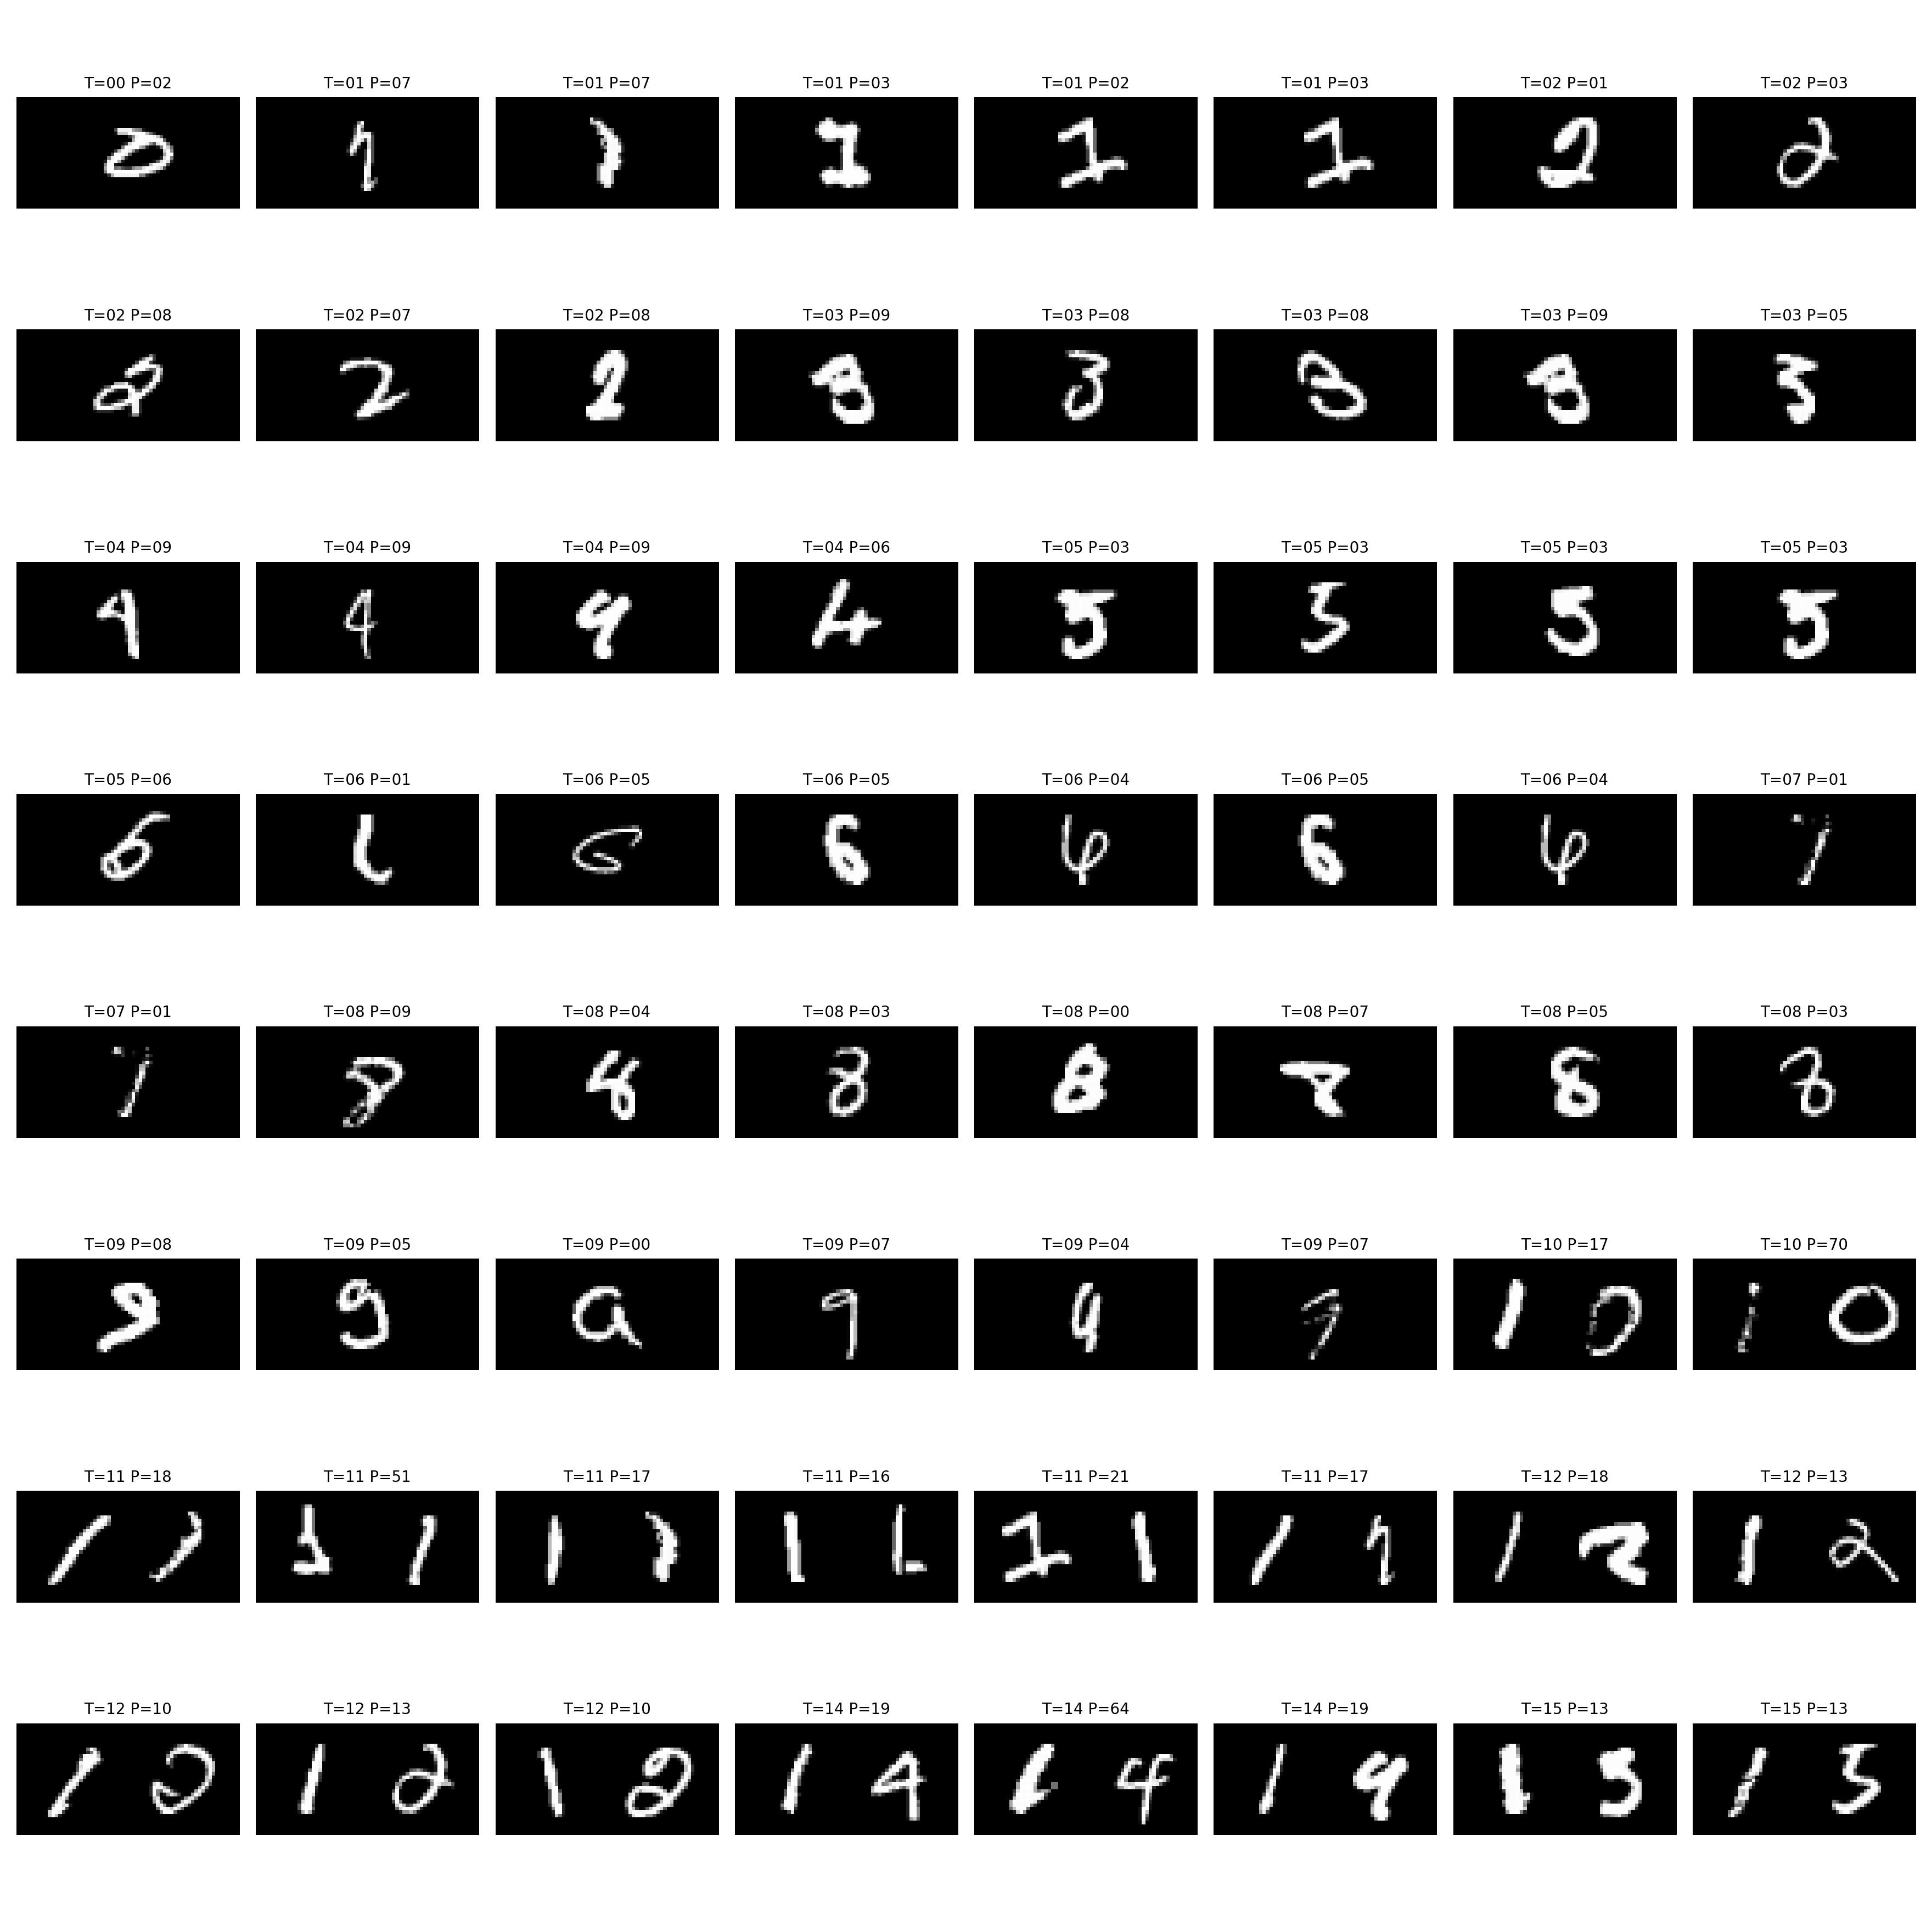

<Figure size 640x480 with 0 Axes>

In [44]:
%run /kaggle/working/eval_lenet99_ablation.py --training_conf /kaggle/working/configs/ablations/A3_poolmax.yaml --ckpt /kaggle/working/checkpoints/A3_poolmax/best.pt --split test --save_dir /kaggle/working/artifacts/ablation/A3_poolmax --max_wrong 64

## Ablation Study

Each run has the same dataset split, number of epochs (10), batch size (256), and seed (42).

**Baseline (A0_base_adam):** This configuration achieved the best overall performance on the test set: **98.48% accuracy** with **loss 0.05695** and **455 wrong predictions**. Performance is slightly higher on single-digit classes (0–9) than on two-digit classes (10–99), as expected, but both are high (0–9: 98.93%, 10–99: 98.43%).

**Optimizer ablation (A1_sgd_momentum):** On the test set this run reached **98.23% accuracy** (loss 0.05770), slightly worse than the baseline (+76 errors). This is consistent with TensorBoard: the SGD run shows **slower convergence** (lower train accuracy and higher train loss in early epochs). With only 10 epochs, SGD needs more careful tuning to match Adam’s performance.

**Dropout ablation (A2_dropout0):** This produced the worst test performance: **97.95% accuracy** with **loss 0.07281** and **615 errors**. The degradation is mainly on the 10–99 classes (97.90%), suggesting reduced regularization hurts generalization on the more complex two-digit images. TensorBoard curves align with this: training accuracy remains high, while validation accuracy is consistently lower and validation loss higher, indicating increased overfitting when dropout is disabled.

**Final pooling ablation (A3_poolmax):** This run achieved **98.13% accuracy** (loss 0.07025), worse than the baseline (+106 errors).

| Run | Specs | Test acc | Test loss | Acc 0–9 | Acc 10–99 | Wrong |
|---|---|---:|---:|---:|---:|---:|
| A0_base_adam | Adam, dropout=0.1, final_pool=avg | **0.9848** | **0.05695** | **0.9893** | **0.9843** | **455** |
| A1_sgd_momentum | SGD+momentum (lr=0.05, wd=5e-4) | 0.9823 | 0.05770 | 0.9837 | 0.9821 | 531 |
| A2_dropout0 | dropout=0.0 | 0.9795 | 0.07281 | 0.9843 | 0.9790 | 615 |
| A3_poolmax | final_pool=max | 0.9813 | 0.07025 | 0.9847 | 0.9809 | 561 |


Overall, the ablation results support the baseline choices: **dropout is important for generalization**, Adam provides faster convergence under our short training budget, and **AvgPool(1×2)** performs better than MaxPool(1×2) for the final anisotropic pooling on this task. 

**20 Epochs:** Another ablation was made to show that validation accuracy increases rapidly and reaches a clear plateau after ~8–10 epochs, while training accuracy keeps improving. At the same time, validation loss starts to oscillate (and slightly rises), suggesting thst 10 epochs is a good tradeoff for this model. This results were archieved by setting 20 epochs in A0_base_adam.yaml and launching the train, then visualizing the curves in TensorBoard.
